# Plug-and-play in silico ChIP

In [1]:
# Input:
# RNA SCE at choosen resolution
# ATAC SCE at choosen resolution
# Both need to contain lognormalised counts
# Both need to be matched & in the right order

In [3]:
###################
## Load packages
###################
suppressPackageStartupMessages({
    library(scran)
    library(scater)
})
source('../insilico_chip/utils.R')

In [6]:
###################
## I/O
###################
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'

## All
io$RNA_sce = file.path(io$basedir, '/results/rna_atac/metacells/SingleCellExperiment_metacells.rds')
io$ATAC_sce = file.path(io$basedir, '/results/rna_atac/metacells/PeakMatrix_summarized_experiment_metacells.rds')

#
io$motifmatcher <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP-Scores.rds")
io$motif2gene <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP_motif2gene.txt.gz")
io$background_peaks = file.path(io$basedir,"/data/processed/atac/archR/Background-Peaks.rds")

# outdir
io$outdir = file.path(io$basedir, 'results/revisions/whole_atlas/')
dir.create(io$outdir, showWarnings=F, recursive=T)

In [7]:
#######################
## Load RNA and ATAC 
#######################

# Load SingleCellExperiment
rna.sce <- readRDS(io$RNA_sce)

# Load ATAC SummarizedExperiment
atac.sce <- readRDS(io$ATAC_sce)

# Normalise ATAC data
assayNames(atac.sce) <- "counts"
assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1)

# Make sure that samples are consistent
samples <- intersect(colnames(rna.sce),colnames(atac.sce))
rna.sce <- rna.sce[,samples]
atac.sce <- atac.sce[,samples]

print(sprintf("Number of metacells: %s",length(samples)))

[1] "Number of metacells: 2406"


In [12]:
# # When starting from single-cell and metacells assignment
# opts = list()
# opts$samples <- c(
#   "E7.5_rep1",
#   "E7.5_rep2",
#   "E7.75_rep1",
#   "E8.0_rep1",
#   "E8.0_rep2",
#   "E8.5_rep1",
#   "E8.5_rep2",
#   "E8.75_rep1",
#   "E8.75_rep2"
# )
# metacell_assignment = lapply(opts$sample, function(x){
#     tmp = fread(file.path(io$metacell_folder, x, '/cell2metacell_assignment.txt.gz'))
#     return(tmp)
# }) %>% rbindlist() %>%
#     .[match(samples, cell)] %>% 
#     .[!is.na(cell)]

# rna.sce <- rna.sce[,metacell_assignment$cell]
# atac.sce <- atac.sce[,metacell_assignment$cell]

# summary(metacell_assignment$cell == colnames(rna.sce))
# summary(metacell_assignment$cell == colnames(atac.sce))

# print(sprintf("Number of metacells: %s",length(unique(metacell_assignment$metacell))))

# library(BiocParallel)
# BPPARAM = MulticoreParam(detectCores())

# rna.pb = aggregateAcrossCells(rna.sce, id=metacell_assignment$metacell, BPPARAM = BPPARAM)
# atac.pb = aggregateAcrossCells(atac.sce, id=metacell_assignment$metacell, BPPARAM = BPPARAM)

# rna.sce_old = rna.sce
# atac.sce_old = atac.sce

# rna.sce = rna.pb
# atac.sce = atac.pb

# summary(colnames(rna.sce) == colnames(atac.sce))

# assay(rna.sce,"logcounts") <- log(1e6*(sweep(assay(rna.sce),2,colSums(assay(rna.sce),na.rm=T),"/"))+1)
# assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1)


In [8]:
# RNA dimreduction

decomp <- modelGeneVar(rna.sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=3000) %>% rownames

sce_filt <- rna.sce[hvgs,]
sce_filt <- runPCA(sce_filt, ncomponents = 35, ntop=3000)

In [9]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 20, min_dist = 0.3)

umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

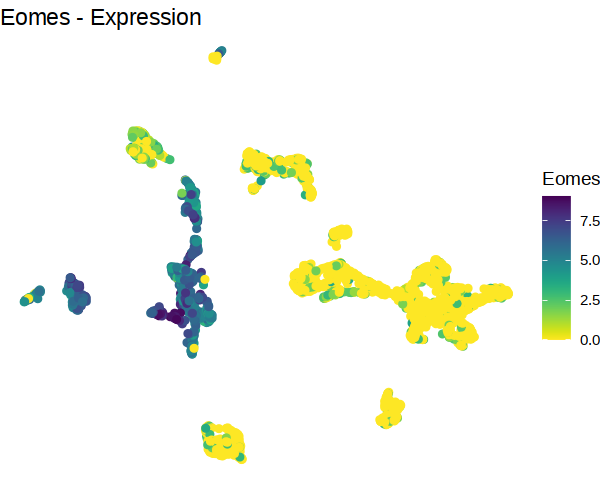

In [22]:
options(repr.plot.width=5, repr.plot.height=4)
gene = 'Eomes'
ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce[gene,], 'logcounts')))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=gene) + 
    ggtitle(paste0(gene, ' - Expression')) + 
    theme_void()

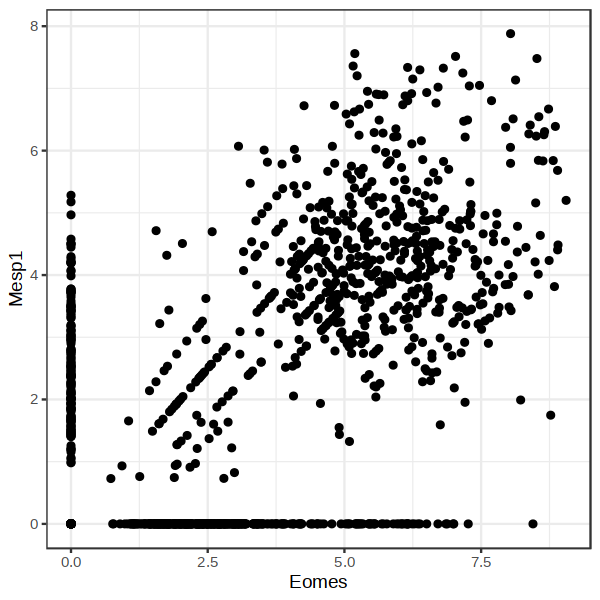

In [23]:
gene1 = 'Eomes'
gene2 = 'Mesp1'
options(repr.plot.width=5, repr.plot.height=5)
ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene1,])), as.vector(logcounts(rna.sce[gene2,])))) + 
                    geom_point() + 
                    xlab(gene1) + ylab(gene2) + 
                    theme_bw()

In [24]:
#######################
## Load Motifs if wanted
#######################
motifmatcher.se <- readRDS(io$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac.sce)))
motifmatcher.se <- motifmatcher.se[rownames(atac.sce),]

motif2gene.dt <- fread(io$motif2gene)

In [25]:
motifmatcher.se

class: RangedSummarizedExperiment 
dim: 192251 871 
metadata(0):
assays(3): motifScores motifMatches motifCounts
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(871): TFAP2B_1 TFAP2D_2 ... TBX22_870 TBXT
colData names(1): name

In [26]:
# ##############################
# ## Recalculate motif matches
# ##############################
# # load packages
# suppressPackageStartupMessages({
#     library(motifmatchr)
#     library(chromVARmotifs)
#     library(BSgenome.Mmusculus.UCSC.mm10)
#     library(GenomicRanges)
# })
# # Get motif data
# data("human_pwms_v2")
# motifs <- human_pwms_v2 # mouse_pwms_v2
# obj <- .summarizeChromVARMotifs(motifs)
#   motifs <- obj$motifs
#   motifSummary <- obj$motifSummary


# # Rename TF motifs
# motifSummary$symbol <- motifSummary$name; motifSummary$name <- NULL
# motifSummary$symbol <- toupper(motifSummary$symbol)
# rename <- c(
# TCFE = "TFE", NKX1 = "NKX1-", NKX2 = "NKX2-", NKX3 = "NKX3-", 
# NKX4 = "NKX4-", NKX5 = "NKX5-", NKX6 = "NKX6-", FOXF1A = "FOXF1", 
# HMGA1RS1 = "RS1", `MYCL1$` = "MYCL", `DUX$` = "DUXF3", `DUXBL$` = "DUXBL1", 
# `PIT1$` = "PROP1", ENSMUSG00000079994 = "SOX1", TCFAP = "TFAP"
# )
# motifSummary$symbol <- stringr::str_replace_all(motifSummary$symbol,rename)

# # Convert peaks to genomic ranges object
# peaks = rownames(atac.sce)
# gr <- GRanges(
#     seqnames = Rle(peaks %>% str_split(':') %>% map_chr(1)),
#     ranges = IRanges(start = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(1)), 
#                      end = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(2))),
#     strand = Rle(rep('*', length(peaks))))

# motifmatcher_scores.out <- matchMotifs(
#   pwms = motifs,
#   subject = gr,
#   genome = BSgenome.Mmusculus.UCSC.mm10,
#   out = "scores",
#   p.cutoff = 0.0001,
#   w = 7
# )

# rownames(motifmatcher_scores.out) = peaks
# motifmatcher.se = motifmatcher_scores.out

In [27]:
###################
## Correlate TF-expr & Region-accessibility
###################  
a = Sys.time()
tf2peak_cor.se = cor_TF_acc(rna.sce, 
                          atac.sce, 
                          TFs_filt = NULL, #str_split(colnames(motifmatcher.se), '_') %>% map_chr(1),  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", #"spearman", # Options for which corrleation method to use
                          remove_motifs = c("T_789"),
                          cores = detectCores()/2)
b = Sys.time()
b-a

[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 738 TFs



Time difference of 4.282027 mins

In [59]:
# Compare with Ricards output
ricard_tf2peak = readRDS(file.path(io$basedir, 'results/revisions/whole_atlas/Ricard/CISBP_cor_TFexpr_vs_peakAcc.rds'))
summary(as.vector(assay(tf2peak_cor.se[, colnames(ricard_tf2peak)])) == as.vector(assay(ricard_tf2peak)))

# Ricards must be an old file from Ricard since the motifmatcher_chip.se overlaps exactly

Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 1.1 GiB”
Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 1.1 GiB”


     Mode     FALSE      TRUE 
  logical  18732174 123149064 

In [16]:
#saveRDS(tf2peak_cor.se, file.path(io$outdir, 'tf2peak_cor.rds'))

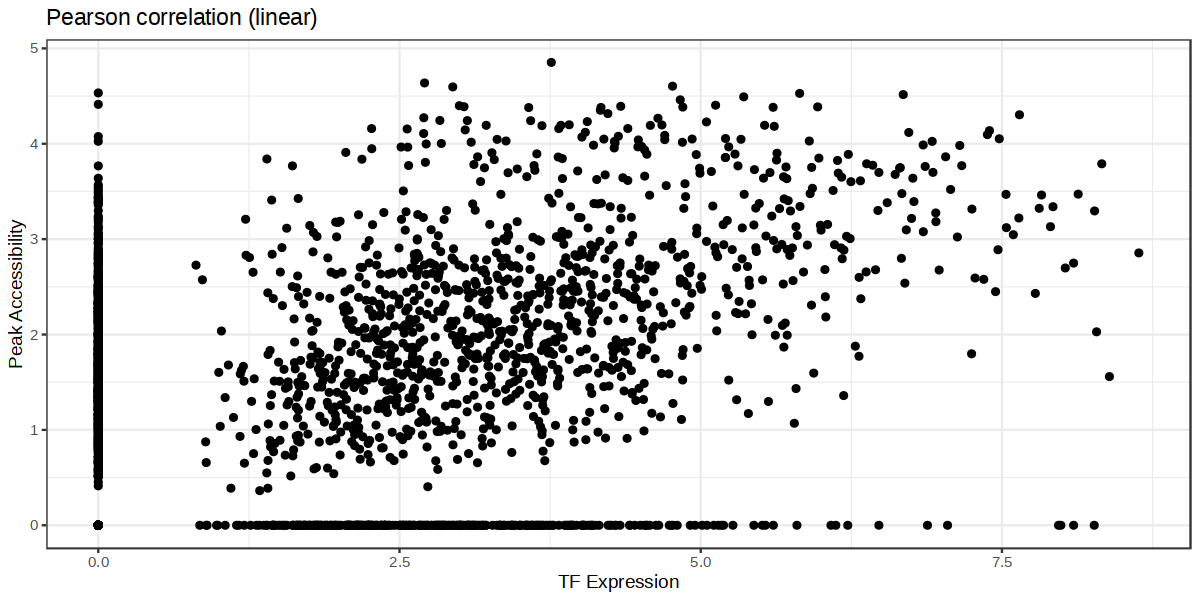

In [35]:
TF = 'GATA2'
i = 1
tmp = as.data.table(as.matrix(assay(tf2peak_cor.se[, TF], 'cor')), keep.rownames=T) %>% setnames(c('peak', 'TF')) %>% .[order(-TF)] %>% head(n=i)
gene = str_to_title(TF)
peak1 = tmp[i,]$peak
p1 = ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene,])), as.vector(assay(atac.sce[peak1,], 'logcounts')))) + 
                    geom_point() + 
                    ggtitle('Pearson correlation (linear)') + 
                    xlab('TF Expression') + ylab('Peak Accessibility') +
                    theme_bw()

options(repr.plot.width=10)
p1

In [36]:
summary(duplicated(colnames(tf2peak_cor.se)))

   Mode   FALSE 
logical     738 

In [37]:
######################################
## Create virtual chip-seq library 
######################################
a = Sys.time()
motifmatcher_chip.se = silico_chip(atac.sce = atac.sce, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, # str_split(colnames(motifmatcher.se), '_') %>% map_chr(1)
                           remove_motifs = c("T_789"),
                           cores = 12)
b = Sys.time()
b-a

[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 738"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


Time difference of 3.796987 mins

In [53]:
motifmatcher_chip.se

class: RangedSummarizedExperiment 
dim: 192251 732 
metadata(0):
assays(4): motifScores motifMatches motifCounts VirtualChipScores
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(732): AHR AHRR ... ZKSCAN4 ZSCAN10
colData names(1): name

Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 1.0 GiB”


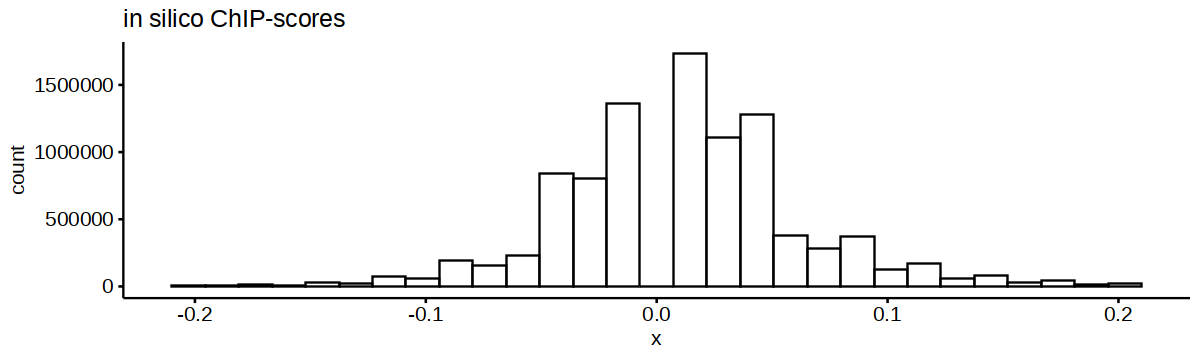

In [38]:
chip_scores = as.vector(assay(motifmatcher_chip.se, 'VirtualChipScores'))
chip_scores = chip_scores[abs(chip_scores)>0.01]
p1 = gghistogram(chip_scores[abs(chip_scores)<quantile(abs(chip_scores), 0.995)], bins=30) + ggtitle('in silico ChIP-scores')
options(repr.plot.width=10, repr.plot.height=3)
p1

In [54]:
# Compare with Ricards
ricard_motifchip = readRDS(file.path(io$basedir, 'results/revisions/whole_atlas/Ricard/motifmatchr_virtual_chip.rds'))
summary(as.vector(assay(motifmatcher_chip.se[, colnames(ricard_motifchip)])) == as.vector(assay(ricard_motifchip)))
# Perfect overlap 

Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 1.0 GiB”
Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 1.0 GiB”


     Mode      TRUE 
  logical 139958728 

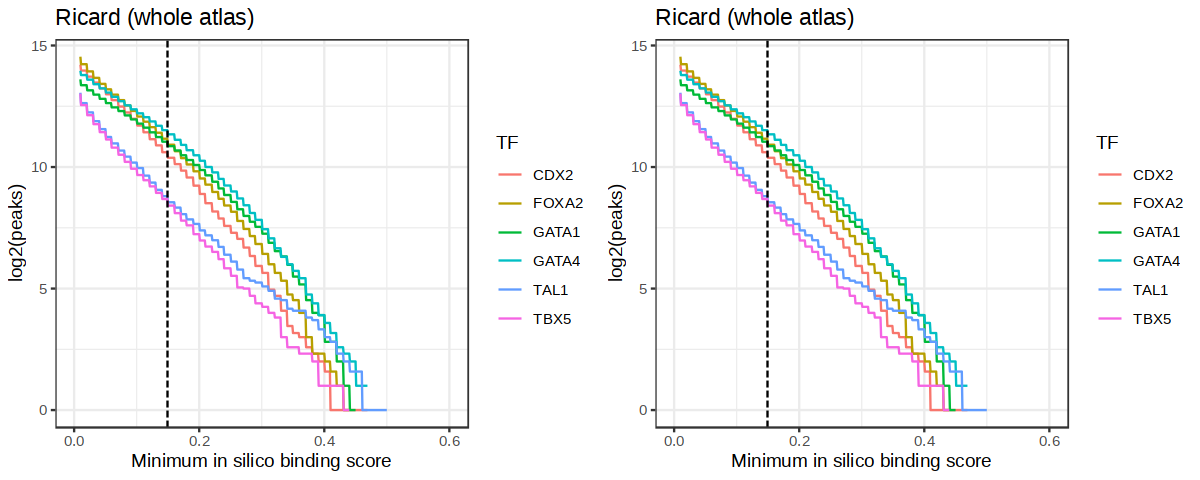

In [56]:
#TFs = c('RUNX1', 'ETV2', 'LYL1', 'EOMES', 'TAL1', 'GATA2', 'MEIS2', 'GATA1', 'CDX2', 'GATA4') # 
TFs = c('CDX2', 'FOXA2', 'GATA1', 'GATA4', 'TAL1', 'TBX5')
chip_scores = as.data.table(as.matrix(assay(motifmatcher_chip.se[,TFs], 'VirtualChipScores')))

chip_cutoff = suppressWarnings(mclapply(seq(0.01, 1, by=0.001), function(x){ #
    tmp = chip_scores %>% melt() %>% setnames(c('TF', 'score')) %>% 
        .[score>=x] %>% 
        .[,N:=.N, by='TF'] %>% unique(by='TF')
                                              
    tmp2 = data.table(N = rep(x, nrow(tmp)),
                      TF = tmp$TF,
                      peaks = tmp$N)
    return(tmp2)
}, mc.cores=12)) %>% rbindlist() %>%
    .[,TF:=factor(TF, levels=TFs)]

p1 = ggplot(chip_cutoff, aes(N, log2(peaks), col=TF, group=TF)) + 
    geom_line() + 
    geom_vline(xintercept=0.15, linetype='longdash') +
    xlab('Minimum in silico binding score') + 
    ggtitle('Bart (whole atlas)') +
    theme_bw()

chip_scores = as.data.table(as.matrix(assay(ricard_motifchip[,TFs], 'VirtualChipScores')))

chip_cutoff = suppressWarnings(mclapply(seq(0.01, 1, by=0.001), function(x){ #
    tmp = chip_scores %>% melt() %>% setnames(c('TF', 'score')) %>% 
        .[score>=x] %>% 
        .[,N:=.N, by='TF'] %>% unique(by='TF')
                                              
    tmp2 = data.table(N = rep(x, nrow(tmp)),
                      TF = tmp$TF,
                      peaks = tmp$N)
    return(tmp2)
}, mc.cores=12)) %>% rbindlist() %>%
    .[,TF:=factor(TF, levels=TFs)]

p1 = ggplot(chip_cutoff, aes(N, log2(peaks), col=TF, group=TF)) + 
    geom_line() + 
    geom_vline(xintercept=0.15, linetype='longdash') +
    xlab('Minimum in silico binding score') + 
    ggtitle('Ricard (whole atlas)') +
    theme_bw()

options(repr.plot.width=10, repr.plot.height=4)
ggarrange(p1+xlim(0, 0.6) , p2+xlim(0, 0.6))

In [78]:
######################################
## ChromVAR - ChIP-seq
######################################
a = Sys.time()
# load background peak set
bgdPeaks.se <- readRDS(io$background_peaks)

chromvar_deviations.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'VirtualChipScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = TRUE, 
                                                   min_chip_score = 0.15,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = 12)
b = Sys.time()
b-a

[1] "Number of matches before filtering negative TF binding values: 18583675"
[1] "Number of matches after filtering negative TF binding values: 11765917"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 11765917"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 161574"
385 TFs removed because they don't have enough binding sites: AHR AHRR ALX3 ALX4 ARID3A ARID5A ARNT ARNTL ARNTL2 ARX ASCL1 ATF1 ATF2 ATF3 ATF4 ATF5 ATF6 ATF6B ATF7 ATOH1 ATOH7 BACH1 BARHL1 BARHL2 BARX1 BARX2 BATF BATF3 BCL6 BCL6B BHLHA15 BHLHE22 BHLHE23 BHLHE40 BHLHE41 BRCA1 BSX CDC5L CEBPA CEBPD CEBPE CEBPG CEBPZ CENPB CIC CLOCK CPEB1 CREB1 CREB3 CREB3L1 CREB3L4 CREB5 CREM CRX CTCFL CUX2 CXXC1 DBP DDIT3 DLX1 DLX2 DLX4 DLX6 DMRT1 DMRT2 DMRT3 DMRTA2 DMRTC2 DNMT1 E2F1 E2F2 E2F3 E2F4 E2F6 E2F7 E2F8 E4F1 EGR2 EGR3 EGR4 EHF ELF1 ELF2 ELF4 ELK1 ELK4 EMX1 EMX2 ERF ESR1 ESR2 ETS2 ETV2 ETV3 ETV4 ETV6 EVX2 FERD3L FEV FEZF1 FEZF2 FIGLA FOSB FOXB2 FOXD4 FOXE1 FOXG1 FOXH1 FOXI2 FOXJ3 FO

as(<lgCMatrix>, "dgCMatrix") is deprecated since Matrix 1.5-0; do as(., "dMatrix") instead



Time difference of 1.133135 mins

In [79]:
TF = 'CDX2'
abs = TRUE
score_thr=1e-10
peaks = rownames(motifmatcher_chip.se)
    tmp = data.table(chr = str_split(peaks, ':') %>% map_chr(1),
                     start = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1),
                     end = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2),
                     score = as.matrix(assay(motifmatcher_chip.se[,TF], 'VirtualChipScores'))) %>%
        setnames(c('chr', 'start', 'end', 'score'))
    if(abs){
        tmp = tmp[abs(score)>=score_thr] 
    }else{
        tmp = tmp[score>=score_thr] 
    }
head(tmp)

chr,start,end,score
<chr>,<chr>,<chr>,<dbl>
chr1,3566755,3567355,0.04
chr1,3648851,3649451,0.06
chr1,3664992,3665592,0.04
chr1,3672237,3672837,0.09
chr1,3681345,3681945,0.02
chr1,3953437,3954037,0.01


In [80]:
save_bed = function(TF, score_thr=1e-10, abs=TRUE){
    peaks = rownames(motifmatcher_chip.se)
    tmp = data.table(chr = str_split(peaks, ':') %>% map_chr(1),
                     start = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1),
                     end = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2),
                     score = as.matrix(assay(motifmatcher_chip.se[,TF], 'VirtualChipScores'))) %>%
        setnames(c('chr', 'start', 'end', 'score'))
    if(abs){
        tmp = tmp[abs(score)>=score_thr] 
    }else{
        tmp = tmp[score>=score_thr] 
    }
    fwrite(tmp, sprintf('%s/silico_chip/%s.bed.gz', io$outdir, TF))
    return(tmp)    
}

beds = mclapply(c('GATA1', 'TAL1', 'CDX2'), save_bed, score_thr=1e-10, abs=TRUE, mc.cores=3) %>% rbindlist()


In [81]:
create_bed = function(TF, score_thr=1e-10){
    peaks = rownames(motifmatcher_chip.se)
    tmp = data.table(chr = str_split(peaks, ':') %>% map_chr(1),
                     start = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1),
                     end = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2),
                     name = TF,
                     score = as.matrix(assay(motifmatcher_chip.se[,TF], 'VirtualChipScores'))) %>%
        setnames(c('chr', 'start', 'end', 'name', 'score')) %>%
        .[score>=score_thr] %>%
        .[,score:=score*1000]
    
    return(tmp)
}

In [82]:
test = create_bed('TAL1', score_thr=-1)

In [83]:
beds = mclapply(c('GATA1', 'TAL1', 'FLI1', 'GATA2'), create_bed, mc.cores=3) %>% rbindlist()
fwrite(beds, file.path(args$outdir, 'beds.bed'), sep='\t', quote=FALSE, col.names = FALSE)

ERROR: Error in args$outdir: object of type 'closure' is not subsettable


In [ ]:
chromvar_deviations_original.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'motifScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = FALSE, 
                                                   min_chip_score = 0,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = detectCores())

In [ ]:
TF = 'CDX2'
if(TF %in% rownames(chromvar_deviations.se) & TF %in% rownames(chromvar_deviations_original.se)){
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce, 'logcounts')[str_to_title(TF),]))) + 
        geom_point() +
        viridis::scale_color_viridis(begin=1, end=0, name=TF) + 
        ggtitle(paste0(TF, ' - Expression')) + 
        theme_void()

    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations.se, 'z')[TF,]))) + 
        geom_point() +
        scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
        ggtitle('ChromVAR-ChIP-seq') + 
        theme_void()

    p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations_original.se, 'z')[TF,]))) + 
        geom_point() +
        scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
        ggtitle('ChromVAR-original') + 
        theme_void()
    options(repr.plot.width=15, repr.plot.height=4)
    ggarrange(p1, p2, p3, nrow = 1)
}

In [ ]:
TF_correlations = mclapply(unique(rownames(chromvar_deviations.se)), function(x){
      corr_output <- psych::corr.test(
        x = as.vector(assay(chromvar_deviations.se[x,], 'z')), 
        y = as.vector(assay(rna.sce[str_to_title(x),], 'logcounts')), 
        ci = FALSE,
        method = 'pearson'
      )
    
    tmp = data.table(tf = x,
                     cor = round(corr_output$r,3),
                     pval = round(corr_output$p,10))
    return(tmp)
}, mc.cores = detectCores()) %>% rbindlist() %>%
    .[order(-cor)] %>%
    .[,rank:=.I]

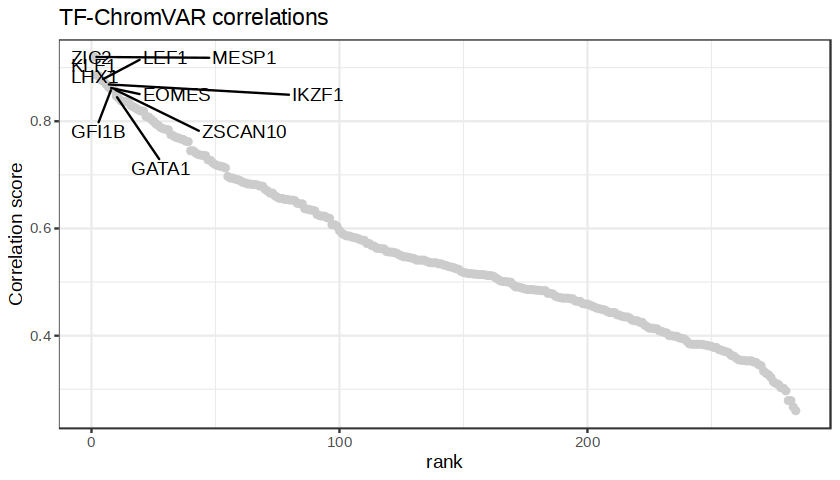

In [41]:
options(repr.plot.width=7, repr.plot.height=4)
ggplot(TF_correlations, aes(rank, cor)) + 
    geom_point(col='gray80') +
    ggrepel::geom_text_repel(data = head(TF_correlations, 10), 
                             aes(label=tf), 
                             max.overlaps=Inf, 
                             box.padding=0.5) + 
    ggtitle('TF-ChromVAR correlations') + 
    ylab('Correlation score') + 
    theme_bw()

In [42]:
######################################
## link TF2genes virtual chip
######################################
# peak2gene (also possible to find them in the function, need to supply gene metadata with gene locations(e.g. from biomaRt))
peak2gene <- file.path(io$basedir,"results/atac/archR/peak_calling/peaks2genes/peaks2genes_all.txt.gz") 

## Load peak2gene linkages using only genomic distance
peak2gene.dt <- fread(peak2gene)
head(peak2gene.dt)
summary(peak2gene.dt$dist)

a = Sys.time()
TF2Gene_links = TF2Gene(rna.sce = rna.sce, 
                   motifmatcher_chip.se = motifmatcher_chip.se,
                   peak2gene.dt = peak2gene.dt,
                   min_chip_score = 0.15,
                   distance = 1.5e5, # Can not be higher than the max distance in peak2gene.dt, unless recalculated from gene metadata file
                   cores = detectCores())
b = Sys.time()
b-a
head(TF2Gene_links)

chr,gene,ens_id,strand,gene.start,gene.end,peak.start,peak.end,peak,peak.mean,dist
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<int>,<dbl>
1,4933401J01Rik,ENSMUSG00000102693,+,3073253,3074322,3035602,3036202,chr1:3035602-3036202,3035902,37351
1,Gm26206,ENSMUSG00000064842,+,3102016,3102125,3035602,3036202,chr1:3035602-3036202,3035902,66114
1,4933401J01Rik,ENSMUSG00000102693,+,3073253,3074322,3062653,3063253,chr1:3062653-3063253,3062953,10300
1,Gm26206,ENSMUSG00000064842,+,3102016,3102125,3062653,3063253,chr1:3062653-3063253,3062953,39063
1,4933401J01Rik,ENSMUSG00000102693,+,3073253,3074322,3072313,3072913,chr1:3072313-3072913,3072613,640
1,Gm26206,ENSMUSG00000064842,+,3102016,3102125,3072313,3072913,chr1:3072313-3072913,3072613,29403


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
      0   14209   42567   43702   71333  100300    5259 

Number of TFs: 237 
Number of genes: 14196 


Time difference of 54.12427 secs

tf,gene,peak,chip_score,dist,beta,pvalue
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
AHR,Abca2,chr2:25432266-25432866,0.16,0,0.437,9.59e-11
AHR,Acaa1a,chr9:119323056-119323656,0.20,16320,0.010,0.84
AHR,Aco2,chr15:81959994-81960594,0.26,45161,0.033,0.103
AHR,Aco2,chr15:81960612-81961212,0.15,45779,0.033,0.103
AHR,Actn4,chr7:29029788-29030388,0.22,67748,-0.193,1.53e-12
AHR,Acvr2b,chr9:119323056-119323656,0.20,78762,-0.188,5.45e-06


In [43]:
head(TF2Gene_links[order(-beta)])

tf,gene,peak,chip_score,dist,beta,pvalue
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
THRA,Hba-x,chr11:32204990-32205590,0.15,71110,2.299,3.77e-36
LMX1A,Hba-x,chr11:32268019-32268619,0.21,8081,2.266,6.32e-24
THRA,Hbb-bh1,chr7:103872953-103873553,0.19,30089,2.161,1.53e-35
NFE2,Hba-x,chr11:32245506-32246106,0.40,30594,2.133,8.35e-64
NFE2,Hba-x,chr11:32250746-32251346,0.40,25354,2.133,8.35e-64
NFE2,Hba-x,chr11:32276239-32276839,0.37,0,2.133,8.35e-64


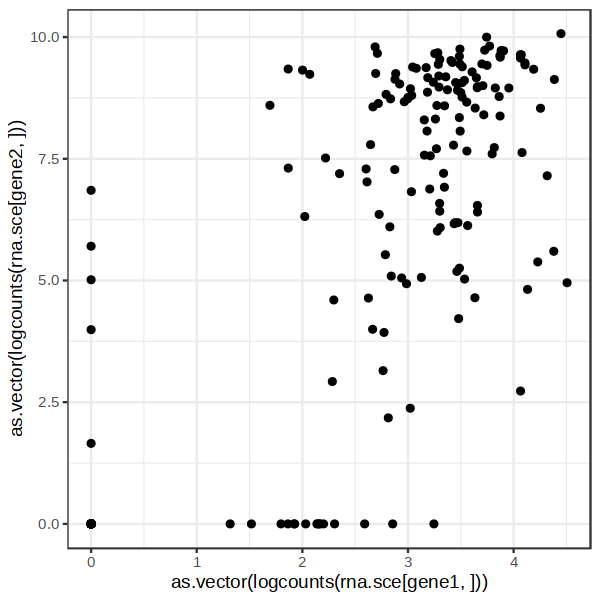

In [44]:
gene1 = 'Nfe2'
gene2 = 'Hba-x'
options(repr.plot.width=5, repr.plot.height=5)
ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene1,])), as.vector(logcounts(rna.sce[gene2,])))) + 
                    geom_point() + 
                    theme_bw()

Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 1.0 GiB”


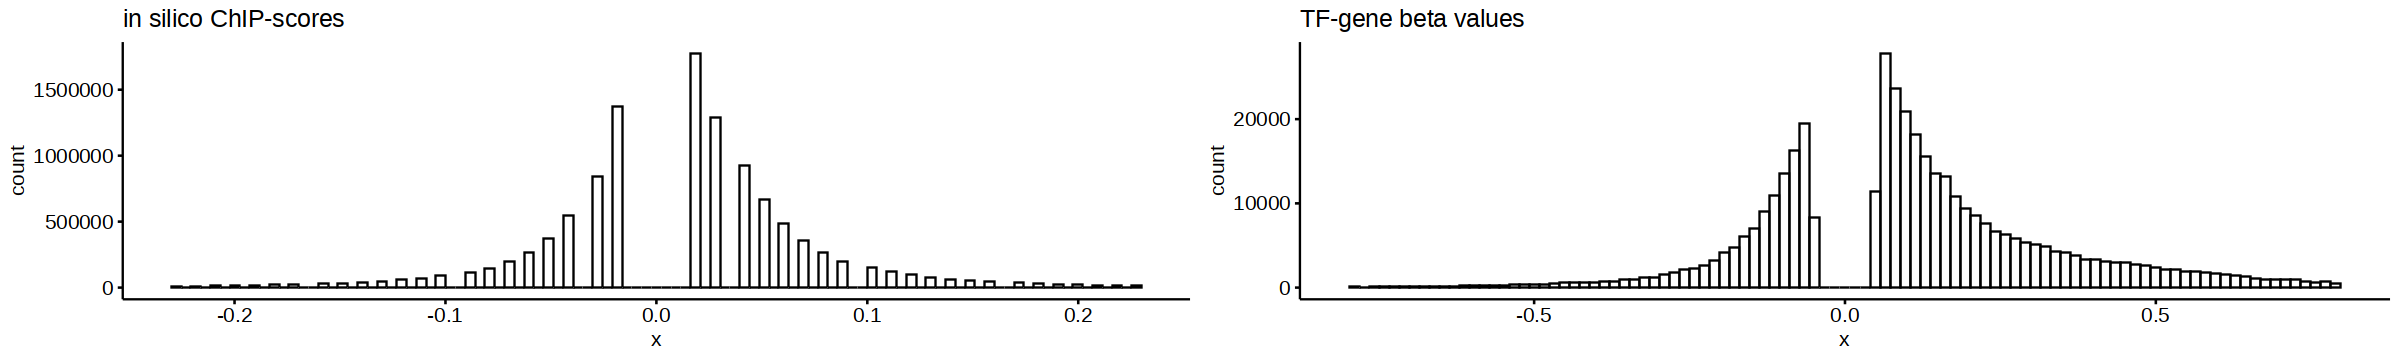

In [45]:
# Inspect silico ChIP-scores & TF-gene beta values
options(repr.plot.width=20, repr.plot.height=3)
chip_scores = as.vector(assay(motifmatcher_chip.se, 'VirtualChipScores'))
chip_scores = chip_scores[abs(chip_scores)>0.01]
p1 = gghistogram(chip_scores[abs(chip_scores)<quantile(abs(chip_scores), 0.99)], bins=100) + ggtitle('in silico ChIP-scores')
p2 = gghistogram(TF2Gene_links$beta[abs(TF2Gene_links$beta)>0.05 & abs(TF2Gene_links$beta)<quantile(abs(TF2Gene_links$beta), 0.99)], bins=100) + ggtitle('TF-gene beta values')
ggarrange(p1, p2)

In [6]:
#######################
## Load RNA and ATAC 
#######################

# Load SingleCellExperiment
rna.sce <- readRDS(io$RNA_sce)

# Load ATAC SummarizedExperiment
atac.sce <- readRDS(io$ATAC_sce)

# Normalise ATAC data
assayNames(atac.sce) <- "counts"
assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1)

# Make sure that samples are consistent
samples <- intersect(colnames(rna.sce),colnames(atac.sce))
rna.sce <- rna.sce[,samples]
atac.sce <- atac.sce[,samples]

print(sprintf("Number of metacells: %s",length(samples)))

[1] "Number of metacells: 329"


In [8]:
# When starting from single-cell and metacells assignment
# opts = list()
# opts$samples <- c(
#   "E7.5_rep1",
#   "E7.5_rep2",
#   "E7.75_rep1",
#   "E8.0_rep1",
#   "E8.0_rep2",
#   "E8.5_rep1",
#   "E8.5_rep2",
#   "E8.75_rep1",
#   "E8.75_rep2"
# )
# metacell_assignment = lapply(opts$sample, function(x){
#     tmp = fread(file.path(io$metacell_folder, x, '/cell2metacell_assignment.txt.gz'))
#     return(tmp)
# }) %>% rbindlist() %>%
#     .[match(samples, cell)] %>% 
#     .[!is.na(cell)]

# rna.sce <- rna.sce[,metacell_assignment$cell]
# atac.sce <- atac.sce[,metacell_assignment$cell]

# summary(metacell_assignment$cell == colnames(rna.sce))
# summary(metacell_assignment$cell == colnames(atac.sce))

# print(sprintf("Number of metacells: %s",length(unique(metacell_assignment$metacell))))

# library(BiocParallel)
# BPPARAM = MulticoreParam(detectCores())

# rna.pb = aggregateAcrossCells(rna.sce, id=metacell_assignment$metacell, BPPARAM = BPPARAM)
# atac.pb = aggregateAcrossCells(atac.sce, id=metacell_assignment$metacell, BPPARAM = BPPARAM)

# rna.sce_old = rna.sce
# atac.sce_old = atac.sce

# rna.sce = rna.pb
# atac.sce = atac.pb

# summary(colnames(rna.sce) == colnames(atac.sce))

# assay(rna.sce,"logcounts") <- log(1e6*(sweep(assay(rna.sce),2,colSums(assay(rna.sce),na.rm=T),"/"))+1)
# assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1)


In [22]:
# RNA dimreduction

decomp <- modelGeneVar(rna.sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=2500) %>% rownames

sce_filt <- rna.sce[hvgs,]
sce_filt <- runPCA(sce_filt, ncomponents = 20, ntop=2500)

In [23]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 20, min_dist = 0.3)

umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

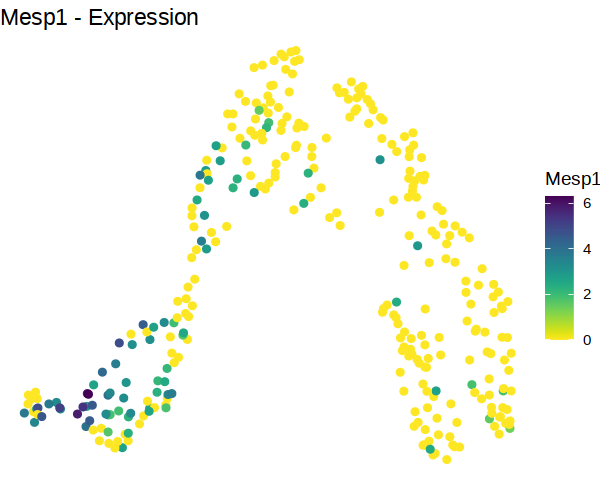

In [24]:
options(repr.plot.width=5, repr.plot.height=4)
gene = 'Mesp1'
ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce[gene,], 'logcounts')))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=gene) + 
    ggtitle(paste0(gene, ' - Expression')) + 
    theme_void()

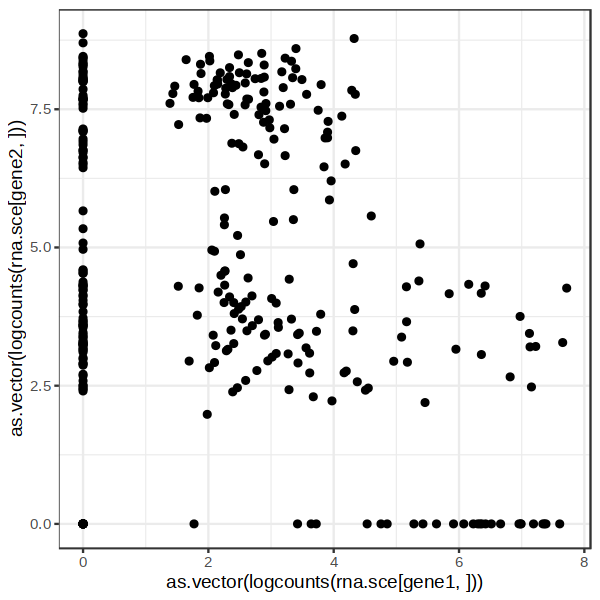

In [26]:
gene1 = 'Foxc2'
gene2 = 'Pax6'
options(repr.plot.width=5, repr.plot.height=5)
ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene1,])), as.vector(logcounts(rna.sce[gene2,])))) + 
                    geom_point() + 
                    theme_bw()

In [28]:
#######################
## Load Motifs if wanted
#######################
motifmatcher.se <- readRDS(io$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac.sce)))
motifmatcher.se <- motifmatcher.se[rownames(atac.sce),]

motif2gene.dt <- fread(io$motif2gene)

In [29]:
motifmatcher.se

class: RangedSummarizedExperiment 
dim: 192251 871 
metadata(0):
assays(3): motifScores motifMatches motifCounts
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(871): TFAP2B_1 TFAP2D_2 ... TBX22_870 TBXT
colData names(1): name

In [33]:
###################
## Correlate TF-expr & Region-accessibility
###################  
source('utils.R')
a = Sys.time()
tf2peak_cor.se = cor_TF_acc(rna.sce, 
                          atac.sce, 
                          TFs_filt = str_split(colnames(motifmatcher.se), '_') %>% map_chr(1),  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", #"spearman", # Options for which corrleation method to use
                          remove_motifs = c("T_789"),
                          cores = detectCores())
b = Sys.time()
b-a

[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 725 TFs



Time difference of 1.288578 mins

In [36]:
tf2peak_cor.se

class: SummarizedExperiment 
dim: 192251 725 
metadata(0):
assays(2): cor pvalue
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(4): seqnames idx start end
colnames(725): SOX17 MYBL1 ... YY2 SRY
colData names(0):

In [54]:
## Non-linear test
source('utils.R')
a = Sys.time()
non_linear_test = cor_TF_acc(rna.sce, 
                          atac.sce, 
                          TFs_filt = str_split(colnames(motifmatcher.se), '_') %>% map_chr(1),  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "spearman", #"spearman", # Options for which corrleation method to use
                          remove_motifs = c("T_789"),
                          cores = detectCores())
b = Sys.time()
b-a


[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 725 TFs



Time difference of 9.871665 mins

ERROR while rich displaying an object: Error in `geom_point()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error in `h()`:
! error in evaluating the argument 'object' in selecting a method for function 'logcounts': unable to find an inherited method for function ‘NSBS’ for signature ‘"list"’

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr

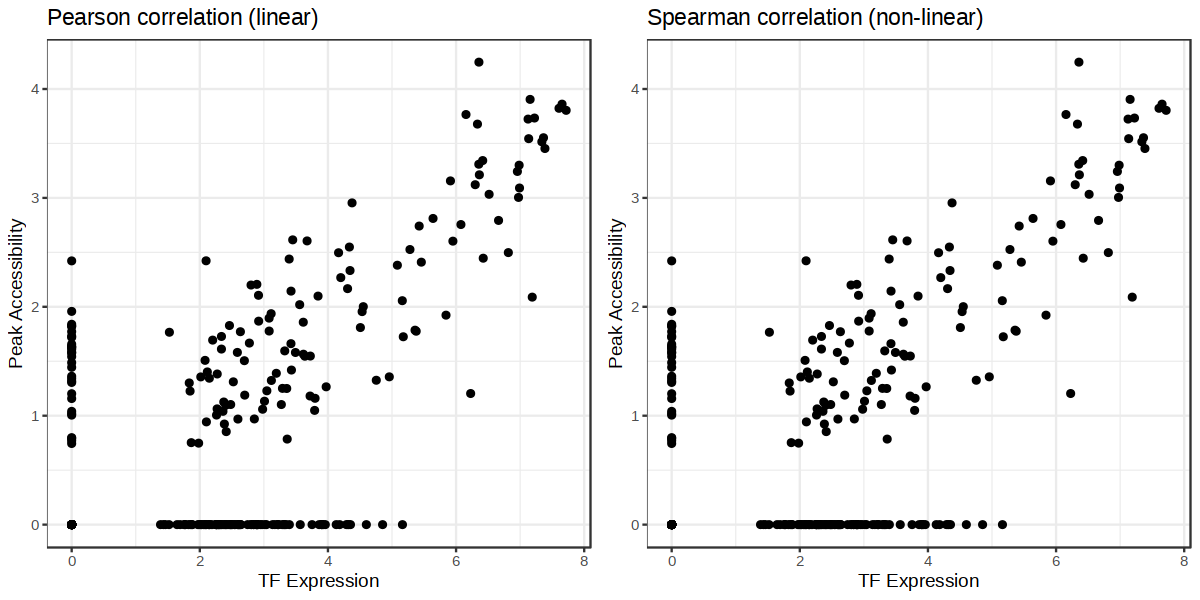

In [121]:
TF = 'FOXC2'
i = 1
tmp = as.data.table(as.matrix(assay(tf2peak_cor.se[, TF], 'cor')), keep.rownames=T) %>% setnames(c('peak', 'TF')) %>% .[order(-TF)] %>% head(n=i)
gene = str_to_title(TF)
peak1 = tmp[i,]$peak
p1 = ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene,])), as.vector(assay(atac.sce[peak1,], 'logcounts')))) + 
                    geom_point() + 
                    ggtitle('Pearson correlation (linear)') + 
                    xlab('TF Expression') + ylab('Peak Accessibility') +
                    theme_bw()

tmp = as.data.table(as.matrix(assay(non_linear_test[, TF], 'cor')), keep.rownames=T) %>% setnames(c('peak', 'TF')) %>% .[order(-TF)] %>% head(n=i)
peak2 = tmp[i,]$peak
options(repr.plot.width=5, repr.plot.height=5)
p2 = ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene,])), as.vector(assay(atac.sce[peak2,], 'logcounts')))) + 
                    geom_point() + 
                    ggtitle('Spearman correlation (non-linear)') + 
                    xlab('TF Expression') + ylab('Peak Accessibility') +
                    theme_bw()
options(repr.plot.width=10)
ggarrange(p1, p2)

In [122]:
summary(duplicated(colnames(tf2peak_cor.se)))

   Mode   FALSE 
logical     725 

In [124]:
######################################
## Create virtual chip-seq library 
######################################
a = Sys.time()
motifmatcher_chip.se = silico_chip(atac.sce = atac.sce, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, 
                           remove_motifs = c("T_789"),
                           cores = detectCores())
b = Sys.time()
b-a

[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 725"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


Time difference of 52.84251 secs

In [125]:
motifmatcher_chip.se

class: RangedSummarizedExperiment 
dim: 192251 709 
metadata(0):
assays(4): motifScores motifMatches motifCounts VirtualChipScores
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(709): AHR AHRR ... ZKSCAN4 ZSCAN10
colData names(1): name

In [126]:
######################################
## ChromVAR - ChIP-seq
######################################
a = Sys.time()
# load background peak set
bgdPeaks.se <- readRDS(io$background_peaks)

chromvar_deviations.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'VirtualChipScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = TRUE, 
                                                   min_chip_score = 0.15,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = detectCores())
b = Sys.time()
b-a

[1] "Number of matches before filtering negative TF binding values: 18442760"
[1] "Number of matches after filtering negative TF binding values: 12229347"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 12229347"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 153087"
506 TFs removed because they don't have enough binding sites: AHR AHRR AIRE ALX1 ALX4 ARID2 ARID5A ARID5B ARNT ARNTL ARNTL2 ARX ASCL1 ASCL2 ATF1 ATF2 ATF3 ATF4 ATF5 ATF6 ATF6B ATF7 ATOH1 ATOH7 BACH1 BACH2 BARHL1 BARHL2 BARX1 BARX2 BATF BATF3 BCL11A BCL11B BCL6 BCL6B BHLHA15 BHLHE22 BHLHE23 BHLHE40 BHLHE41 BPTF BRCA1 BSX CBFB CDC5L CEBPA CEBPB CEBPD CEBPG CEBPZ CENPB CIC CLOCK CPEB1 CREB1 CREB3 CREB3L1 CREB3L3 CREB3L4 CREB5 CREM CRX CTCF CTCFL CUX1 CUX2 CXXC1 DBP DDIT3 DLX1 DLX2 DLX3 DLX4 DLX6 DMBX1 DMRT1 DMRT3 DMRTA2 DMRTC2 DNMT1 E2F1 E2F3 E2F4 E2F5 E2F6 E2F7 E2F8 E4F1 EGR1 EGR2 EGR3 EGR4 EHF ELF1 ELF3 ELF4 ELF5 ELK1 ELK4 EMX1 EMX2 EN1 EN2 EOMES EP300 EPAS1 ERF ERG ESR1 ESR

as(<lgCMatrix>, "dgCMatrix") is deprecated since Matrix 1.5-0; do as(., "dMatrix") instead



Time difference of 58.34474 secs

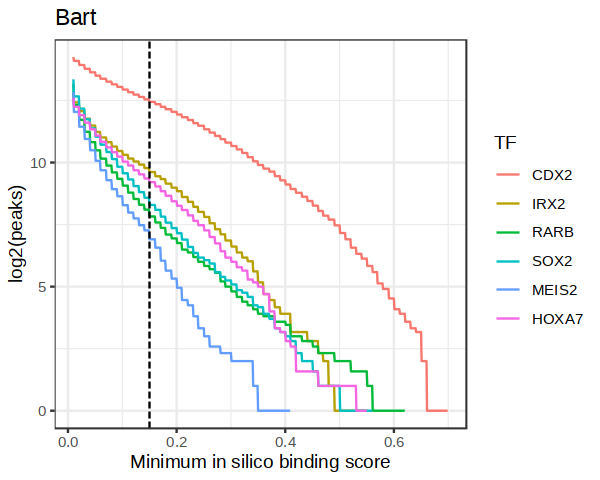

In [258]:
TFs = c('CDX2', 'IRX2', 'RARB', 'SOX2', 'MEIS2', 'HOXA7')
chip_scores = as.data.table(as.matrix(assay(motifmatcher_chip.se[,TFs], 'VirtualChipScores')))

chip_cutoff = suppressWarnings(mclapply(seq(0.01, 0.8, by=0.001), function(x){ #
    tmp = chip_scores %>% melt() %>% setnames(c('TF', 'score')) %>% 
        .[score>=x] %>% 
        .[,N:=.N, by='TF'] %>% unique(by='TF')
                                              
    tmp2 = data.table(N = rep(x, nrow(tmp)),
                      TF = tmp$TF,
                      peaks = tmp$N)
    return(tmp2)
}, mc.cores=detectCores())) %>% rbindlist()

options(repr.plot.width=5, repr.plot.height=4)
ggplot(chip_cutoff, aes(N, log2(peaks), col=TF, group=TF)) + 
    geom_line() + 
    geom_vline(xintercept=0.15, linetype='longdash') +
    xlab('Minimum in silico binding score') + 
    ggtitle('Bart') +
    theme_bw()

[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


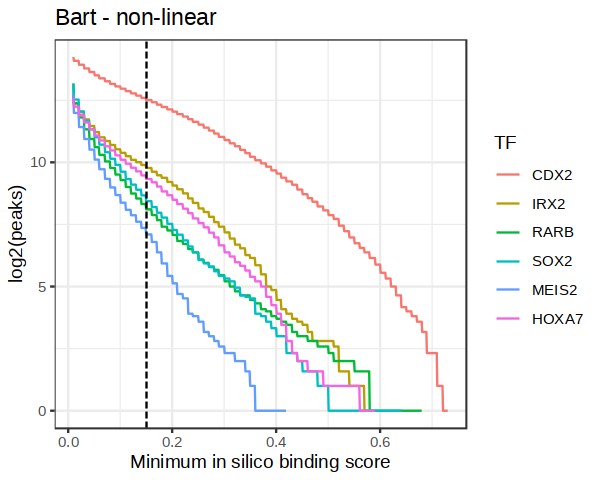

In [264]:
motifmatcher_nonlinear = silico_chip(atac.sce = atac.sce, 
                           tf2peak_cor.se = non_linear_test,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = TFs, 
                           remove_motifs = c("T_789"),
                           cores = detectCores())

chip_scores = as.data.table(as.matrix(assay(motifmatcher_nonlinear[,TFs], 'VirtualChipScores')))

chip_cutoff = suppressWarnings(mclapply(seq(0.01, 0.8, by=0.001), function(x){ #
    tmp = chip_scores %>% melt() %>% setnames(c('TF', 'score')) %>% 
        .[score>=x] %>% 
        .[,N:=.N, by='TF'] %>% unique(by='TF')
                                              
    tmp2 = data.table(N = rep(x, nrow(tmp)),
                      TF = tmp$TF,
                      peaks = tmp$N)
    return(tmp2)
}, mc.cores=detectCores())) %>% rbindlist()

options(repr.plot.width=5, repr.plot.height=4)
ggplot(chip_cutoff, aes(N, log2(peaks), col=TF, group=TF)) + 
    geom_line() + 
    geom_vline(xintercept=0.15, linetype='longdash') +
    xlab('Minimum in silico binding score') + 
    ggtitle('Bart - non-linear') +
    theme_bw()

Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 1 has 29763 rows but longest item has 31333; recycled with remainder.”
Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 2 has 15529 rows but longest item has 31333; recycled with remainder.”
Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 4 has 22897 rows but longest item has 31333; recycled with remainder.”
Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 5 has 21670 rows but longest item has 31333; recycled with remainder.”
Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 6 has 12313 rows but longest item has 31333; recycled with remainder.”


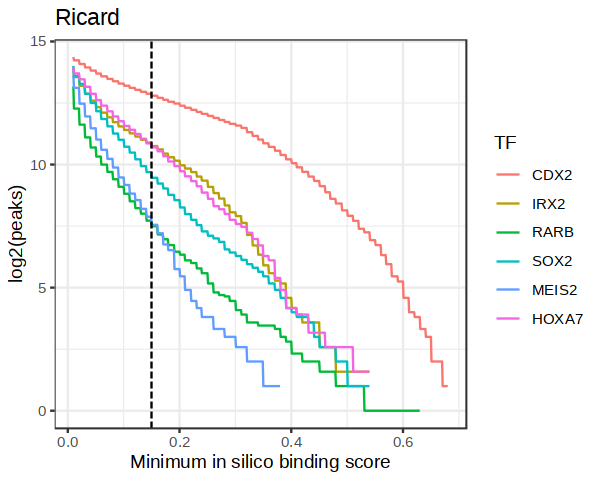

In [259]:
ricard_chip = lapply(TFs, function(x){
    tmp = fread(sprintf('%s/results/rna_atac/virtual_chipseq/metacells/trajectories/nmp/CISBP/%s.txt.gz',io$basedir, x)) %>%
        .[,'score'] %>% setnames(x)
    return(tmp)
}) %>% do.call('cbind', .)

ricard_cutoff = suppressWarnings(mclapply(seq(0.01, 0.8, by=0.001), function(x){ #
    tmp = ricard_chip %>% melt() %>% setnames(c('TF', 'score')) %>% 
        .[score>=x] %>% 
        .[,N:=.N, by='TF'] %>% unique(by='TF')
                                              
    tmp2 = data.table(N = rep(x, nrow(tmp)),
                      TF = tmp$TF,
                      peaks = tmp$N)
    return(tmp2)
}, mc.cores=detectCores())) %>% rbindlist()

options(repr.plot.width=5, repr.plot.height=4)
ggplot(ricard_cutoff, aes(N, log2(peaks), col=TF, group=TF)) + 
    geom_line() + 
    geom_vline(xintercept=0.15, linetype='longdash') +
    xlab('Minimum in silico binding score') + 
    ggtitle('Ricard') +
    theme_bw()

In [288]:
cdx2_ricard = fread(sprintf('%s/results/rna_atac/virtual_chipseq/metacells/trajectories/nmp/CISBP/CDX2.txt.gz',io$basedir)) %>% 
    .[order(-score)] %>% 
    .[,c('peak', 'score')]

cdx2_bart = as.data.table(as.matrix(assay(motifmatcher_chip.se[, 'CDX2'], 'VirtualChipScores'))) %>% 
    .[,peak:=rownames(motifmatcher_chip.se)] %>%
    .[order(-CDX2)] %>% 
    .[,c('peak', 'CDX2')]

In [128]:
chromvar_deviations_original.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'motifScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = FALSE, 
                                                   min_chip_score = 0,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = detectCores())

[1] "Number of matches before filtering based on minimum ChIP-seq score: 18442760"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 18442760"
Running ChromVAR-ChIP-seq (ArchR implementation) 


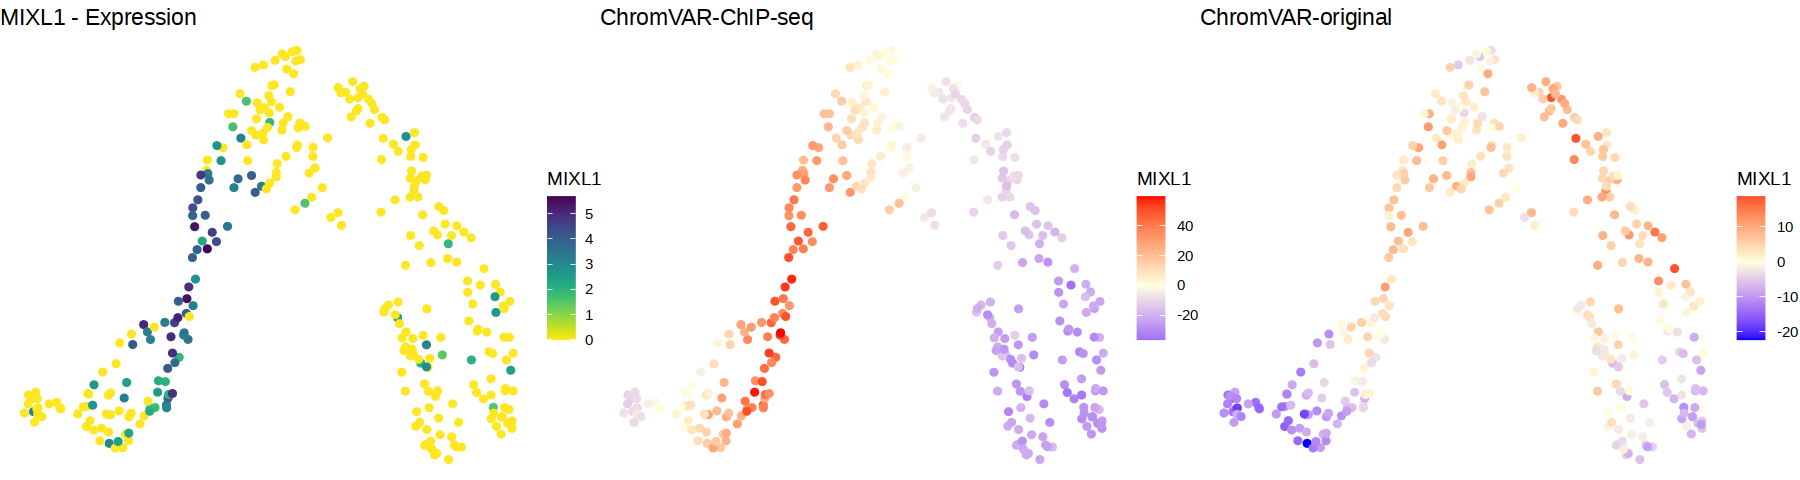

In [244]:
TF = 'MIXL1'
if(TF %in% rownames(chromvar_deviations.se) & TF %in% rownames(chromvar_deviations_original.se)){
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce, 'logcounts')[str_to_title(TF),]))) + 
        geom_point() +
        viridis::scale_color_viridis(begin=1, end=0, name=TF) + 
        ggtitle(paste0(TF, ' - Expression')) + 
        theme_void()

    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations.se, 'z')[TF,]))) + 
        geom_point() +
        scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
        ggtitle('ChromVAR-ChIP-seq') + 
        theme_void()

    p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations_original.se, 'z')[TF,]))) + 
        geom_point() +
        scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
        ggtitle('ChromVAR-original') + 
        theme_void()
    options(repr.plot.width=15, repr.plot.height=4)
    ggarrange(p1, p2, p3, nrow = 1)
}

In [137]:
TF_correlations = mclapply(unique(rownames(chromvar_deviations.se)), function(x){
      corr_output <- psych::corr.test(
        x = as.vector(assay(chromvar_deviations.se[x,], 'z')), 
        y = as.vector(assay(rna.sce[str_to_title(x),], 'logcounts')), 
        ci = FALSE,
        method = 'pearson'
      )
    
    tmp = data.table(tf = x,
                     cor = round(corr_output$r,3),
                     pval = round(corr_output$p,10))
    return(tmp)
}, mc.cores = detectCores()) %>% rbindlist() %>%
    .[order(-cor)] %>%
    .[,rank:=.I]

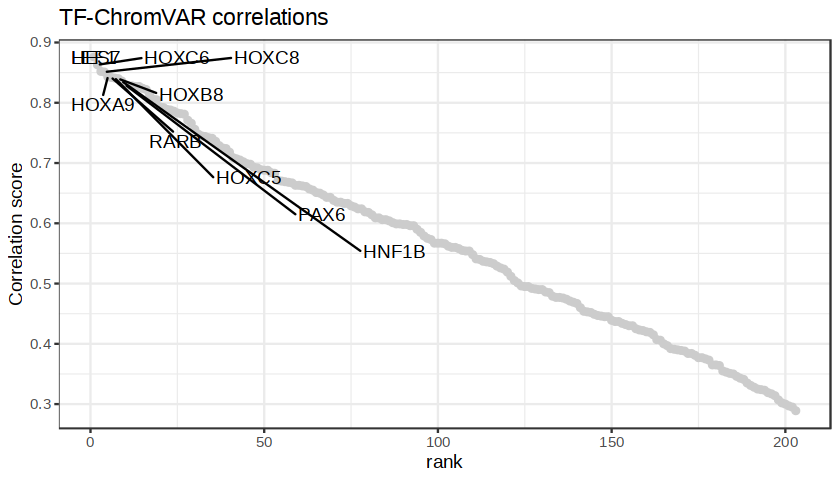

In [142]:
options(repr.plot.width=7, repr.plot.height=4)
ggplot(TF_correlations, aes(rank, cor)) + 
    geom_point(col='gray80') +
    ggrepel::geom_text_repel(data = head(TF_correlations, 10), 
                             aes(label=tf), 
                             max.overlaps=Inf, 
                             box.padding=0.5) + 
    ggtitle('TF-ChromVAR correlations') + 
    ylab('Correlation score') + 
    theme_bw()

In [315]:
######################################
## link TF2genes virtual chip
######################################
# peak2gene (also possible to find them in the function, need to supply gene metadata with gene locations(e.g. from biomaRt))
peak2gene <- file.path(io$basedir,"results/atac/archR/peak_calling/peaks2genes/peaks2genes_all.txt.gz") 

## Load peak2gene linkages using only genomic distance
peak2gene.dt <- fread(peak2gene)
head(peak2gene.dt)
summary(peak2gene.dt$dist)

a = Sys.time()
TF2Gene_links = TF2Gene(rna.sce = rna.sce, 
                   motifmatcher_chip.se = motifmatcher_chip.se,
                   peak2gene.dt = peak2gene.dt,
                   min_chip_score = 0.05,
                   distance = 1.5e5, # Can not be higher than the max distance in peak2gene.dt, unless recalculated from gene metadata file
                   cores = detectCores())
b = Sys.time()
b-a
head(TF2Gene_links)

chr,gene,ens_id,strand,gene.start,gene.end,peak.start,peak.end,peak,peak.mean,dist
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<int>,<dbl>
1,4933401J01Rik,ENSMUSG00000102693,+,3073253,3074322,3035602,3036202,chr1:3035602-3036202,3035902,37351
1,Gm26206,ENSMUSG00000064842,+,3102016,3102125,3035602,3036202,chr1:3035602-3036202,3035902,66114
1,4933401J01Rik,ENSMUSG00000102693,+,3073253,3074322,3062653,3063253,chr1:3062653-3063253,3062953,10300
1,Gm26206,ENSMUSG00000064842,+,3102016,3102125,3062653,3063253,chr1:3062653-3063253,3062953,39063
1,4933401J01Rik,ENSMUSG00000102693,+,3073253,3074322,3072313,3072913,chr1:3072313-3072913,3072613,640
1,Gm26206,ENSMUSG00000064842,+,3102016,3102125,3072313,3072913,chr1:3072313-3072913,3072613,29403


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
      0   14209   42567   43702   71333  100300    5259 

Number of TFs: 369 
Number of genes: 14916 


Time difference of 2.771827 mins

tf,gene,beta,pvalue
<chr>,<chr>,<dbl>,<chr>
AHR,Frs2,-0.031,0.0764
ALX3,Frs2,0.055,0.0228
ARID3C,Frs2,-0.035,0.0631
ARID5B,Frs2,0.085,0.000266
ARNTL,Frs2,-0.012,0.459
ASCL2,Frs2,0.022,0.366


In [326]:
head(TF2Gene_links[order(-beta)])

tf,gene,beta,pvalue
<chr>,<chr>,<dbl>,<chr>
TCF7L2,Galntl6,1.973,6.18e-31
GLI2,Galntl6,1.911,8.87e-29
TCF7L2,Rarb,1.897,8.96e-54
HOXB4,Epha5,1.878,7.97e-60
HOXB1,Rspo3,1.870,3.53e-47
GLI2,Nrg3,1.841,3.85e-40


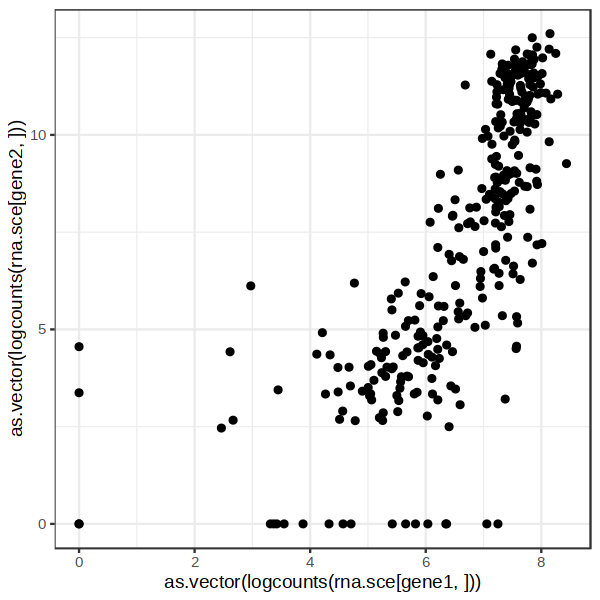

In [327]:
gene1 = 'Hoxb4'
gene2 = 'Epha5'
options(repr.plot.width=5, repr.plot.height=5)
ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene1,])), as.vector(logcounts(rna.sce[gene2,])))) + 
                    geom_point() + 
                    theme_bw()

Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 1.0 GiB”


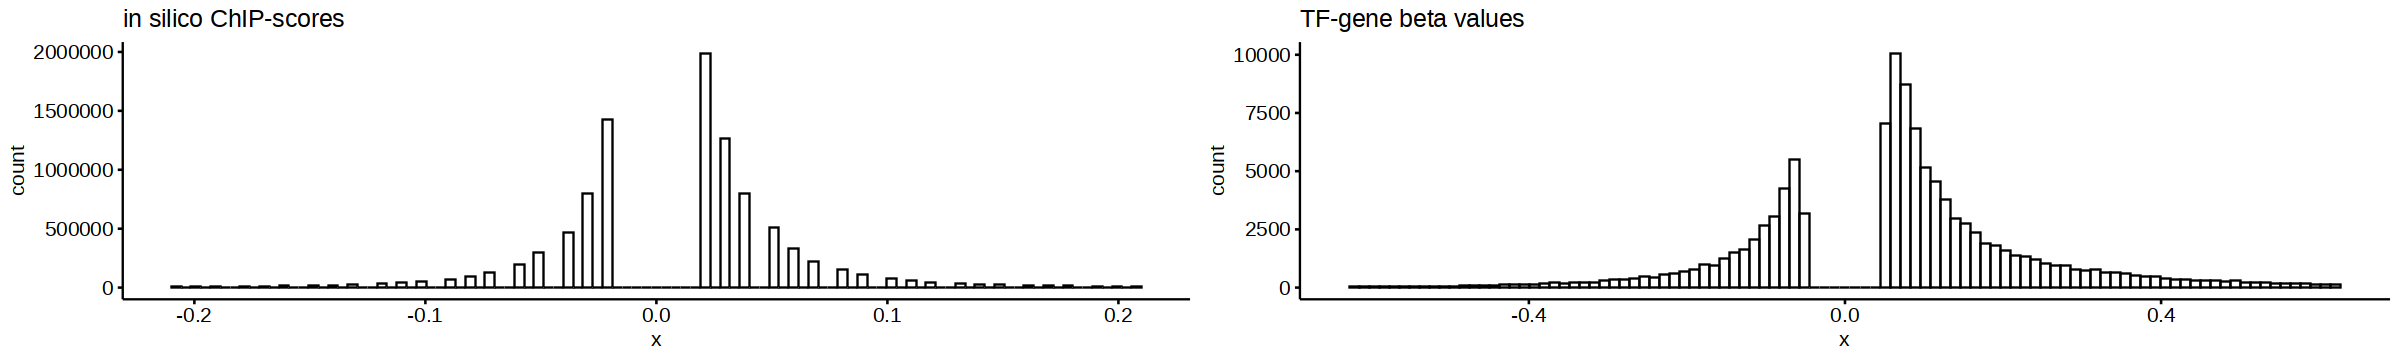

In [144]:
# Inspect silico ChIP-scores & TF-gene beta values
options(repr.plot.width=20, repr.plot.height=3)
chip_scores = as.vector(assay(motifmatcher_chip.se, 'VirtualChipScores'))
chip_scores = chip_scores[abs(chip_scores)>0.01]
p1 = gghistogram(chip_scores[abs(chip_scores)<quantile(abs(chip_scores), 0.99)], bins=100) + ggtitle('in silico ChIP-scores')
p2 = gghistogram(TF2Gene_links$beta[abs(TF2Gene_links$beta)>0.05 & abs(TF2Gene_links$beta)<quantile(abs(TF2Gene_links$beta), 0.99)], bins=100) + ggtitle('TF-gene beta values')
ggarrange(p1, p2)

In [306]:
suppressMessages(library(GGally))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(igraph))
suppressMessages(library(tibble))
suppressMessages(library(tidygraph))

In [298]:
tf2gene_chip = function(motifmatcher_chip.se = motifmatcher_chip.se,
                        assay = 'VirtualChipScores',
                        max_distance = 1.5e5,
                        min_chip_score = 0.1,
                        min_beta = 0.1,
                        min_pvalue = 0.1,
                        min_TF_expr = 5, # Min logcounts
                        TF_filter = NULL, #c('GATA1', 'TAL1', 'HOXB8', 'LYL1')#c('HOXB8')
                        TF_TF_only = TRUE,
                        rna.sce = rna.sce,
                        min_targets = 3,
                        cores = detectCores()
                        ){
    
    tf2gene_chip.dt = mclapply(colnames(assay(motifmatcher_chip.se, assay)), function(i){
            virtual_chip.mtx = assay(motifmatcher_chip.se, assay)
            # Select target peaks (note that we only take positive correlations into account)
            target_peaks_i <- names(which(virtual_chip.mtx[,i]>=min_chip_score))
            if (length(target_peaks_i)>=1) {
                tmp <- data.table(
                  tf = i,
                  peak = target_peaks_i,
                  chip_score = virtual_chip.mtx[target_peaks_i,i]
                ) %>% merge(peak2gene.dt[peak %in% target_peaks_i,c("peak","gene","dist")], by="peak")
                return(tmp)
                }
            }, mc.cores=cores) %>% rbindlist %>%
            .[,gene:=toupper(gene)] %>%
            .[chip_score >= min_chip_score & dist <= max_distance]

    options(repr.plot.width=6, repr.plot.height=3)
    max_expr = data.table(tf = unique(tf2gene_chip.dt$tf),
                          max_expr = rowMaxs(logcounts(rna.sce[str_to_title(unique(tf2gene_chip.dt$tf)),])))

    gghistogram(max_expr$max_expr) + ggtitle('Max expression of TFs')
    TF_keep = max_expr[max_expr>=min_TF_expr, toupper(tf)]

    GRN_coef.dt <- TF2Gene_links %>% 
      .[pvalue<min_pvalue & abs(beta)>=min_beta] %>%
      .[,gene:=toupper(gene)] %>%
      .[tf %in% TF_keep]
    if(!is.null(TF_filter)){
        GRN_coef.dt = GRN_coef.dt[tf %in% TF_filter]
    }
    if(TF_TF_only){
        GRN_coef.dt = GRN_coef.dt[gene %in% tf]
    }

    GRN.dt = merge(GRN_coef.dt, tf2gene_chip.dt, by=c('tf', 'gene')) %>% 
        .[,c('tf', 'peak', 'gene', 'dist', 'chip_score', 'beta', 'pvalue')] %>% 
        unique(by=c('tf', 'gene')) %>%
        .[,c('tf', 'gene', 'beta')] %>% 
        .[,N := .N, by='tf'] %>%
        .[N >= min_targets] 

    if(TF_TF_only){
        GRN.dt = GRN.dt[gene %in% tf]
    }
    
    return(GRN.dt)
}

In [301]:
test = tf2gene_chip(motifmatcher_chip.se = motifmatcher_chip.se,
                        assay = 'VirtualChipScores',
                        max_distance = 1.5e5,
                        min_chip_score = 0.1,
                        min_beta = 0.1,
                        min_pvalue = 0.1,
                        min_TF_expr = 5, # Min logcounts
                        TF_filter = NULL, #c('GATA1', 'TAL1', 'HOXB8', 'LYL1')#c('HOXB8')
                        TF_TF_only = TRUE,
                        rna.sce = rna.sce,
                        min_targets = 3,
                        cores = detectCores())
head(test)

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


tf,gene,beta,N
<chr>,<chr>,<dbl>,<int>
BCL11B,CDX1,0.181,21
BCL11B,FOXC2,-0.204,21
BCL11B,HAND1,0.110,21
BCL11B,HOXA4,0.216,21
BCL11B,HOXA5,0.193,21
BCL11B,HOXB1,0.124,21


In [84]:
#################
## Build GRN
#################
max_distance = 1.5e5
min_chip_score = 0.1
min_beta = 0.1
min_pvalue = 0.1
min_TF_expr = 5 # Min logcounts
TF_filter = NULL #c('GATA1', 'TAL1', 'HOXB8', 'LYL1')#c('HOXB8')
TF_TF_only = TRUE
motifmatcher_chip.se = motifmatcher_chip.se
assay = 'VirtualChipScores'
rna.sce = rna.sce
min_targets = 3
cores = detectCores()

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


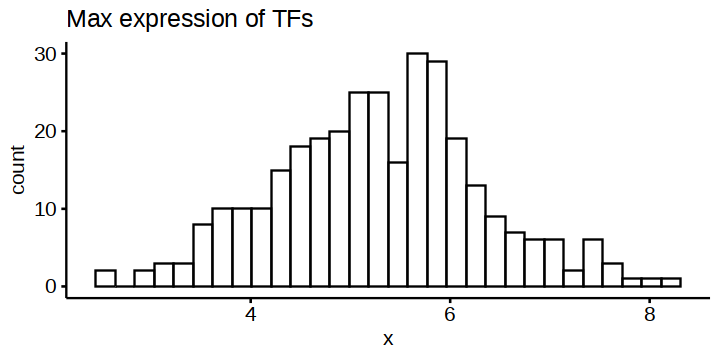

In [85]:
tf2gene_chip.dt <- mclapply(colnames(assay(motifmatcher_chip.se, assay)), function(i){
        virtual_chip.mtx = assay(motifmatcher_chip.se, assay)
        # Select target peaks (note that we only take positive correlations into account)
        target_peaks_i <- names(which(virtual_chip.mtx[,i]>=min_chip_score))
        if (length(target_peaks_i)>=1) {
            tmp <- data.table(
              tf = i,
              peak = target_peaks_i,
              chip_score = virtual_chip.mtx[target_peaks_i,i]
            ) %>% merge(peak2gene.dt[peak %in% target_peaks_i,c("peak","gene","dist")], by="peak")
            return(tmp)
            }
        }, mc.cores=cores) %>% rbindlist %>%
        .[,gene:=toupper(gene)] %>%
        .[chip_score >= min_chip_score & dist <= max_distance]

options(repr.plot.width=6, repr.plot.height=3)
max_expr = data.table(tf = unique(tf2gene_chip.dt$tf),
                      max_expr = rowMaxs(logcounts(rna.sce[str_to_title(unique(tf2gene_chip.dt$tf)),])))

gghistogram(max_expr$max_expr) + ggtitle('Max expression of TFs')
TF_keep = max_expr[max_expr>=min_TF_expr, toupper(tf)]

GRN_coef.dt <- TF2Gene_links %>% 
  .[pvalue<min_pvalue & abs(beta)>=min_beta] %>%
  .[,gene:=toupper(gene)] %>%
  .[tf %in% TF_keep]
if(!is.null(TF_filter)){
    GRN_coef.dt = GRN_coef.dt[tf %in% TF_filter]
}
if(TF_TF_only){
    GRN_coef.dt = GRN_coef.dt[gene %in% tf]
}

GRN.dt = merge(GRN_coef.dt, tf2gene_chip.dt, by=c('tf', 'gene')) %>% 
    .[,c('tf', 'peak', 'gene', 'dist', 'chip_score', 'beta', 'pvalue')] %>% 
    unique(by=c('tf', 'gene')) %>%
    .[,c('tf', 'gene', 'beta')] %>% 
    .[,N := .N, by='tf'] %>%
    .[N >= min_targets] 

if(TF_TF_only){
    GRN.dt = GRN.dt[gene %in% tf]
}

In [307]:
# Create node and edge data.frames
TFs <- unique(c(GRN.dt$tf,GRN.dt$gene))
node_list.dt <- data.table(node_id=1:length(TFs), node_name=TFs)
edge_list.dt <- GRN.dt[,c("tf","gene","beta")] %>% setnames(c("from","to","weight")) %>% .[!from==to]

# Create igraph object
igraph.net <- graph_from_data_frame(d = edge_list.dt)

# Create tbl_graph object for ggraph
igraph.tbl <- as_tbl_graph(igraph.net) %>%
  activate(nodes) %>%
  mutate(tf=names(V(igraph.net))) %>%
  mutate(degree=igraph::degree(igraph.net)) %>%
  mutate(eigen_centrality=eigen_centrality(igraph.net)$vector) %>%
  activate(edges) %>%
  mutate(sign=ifelse(E(igraph.net)$weight>0,"Positive","Negative")) %>%
  mutate(weight=abs(weight))

Warning message in eigen_centrality(igraph.net):
“At core/centrality/centrality_other.c:184 : Negative weight in graph. The largest eigenvalue will be selected, but it may not be the largest in magnitude.”


Warning message:
“Using the `size` aesthetic in this geom was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` in the `default_aes` field and elsewhere instead.”


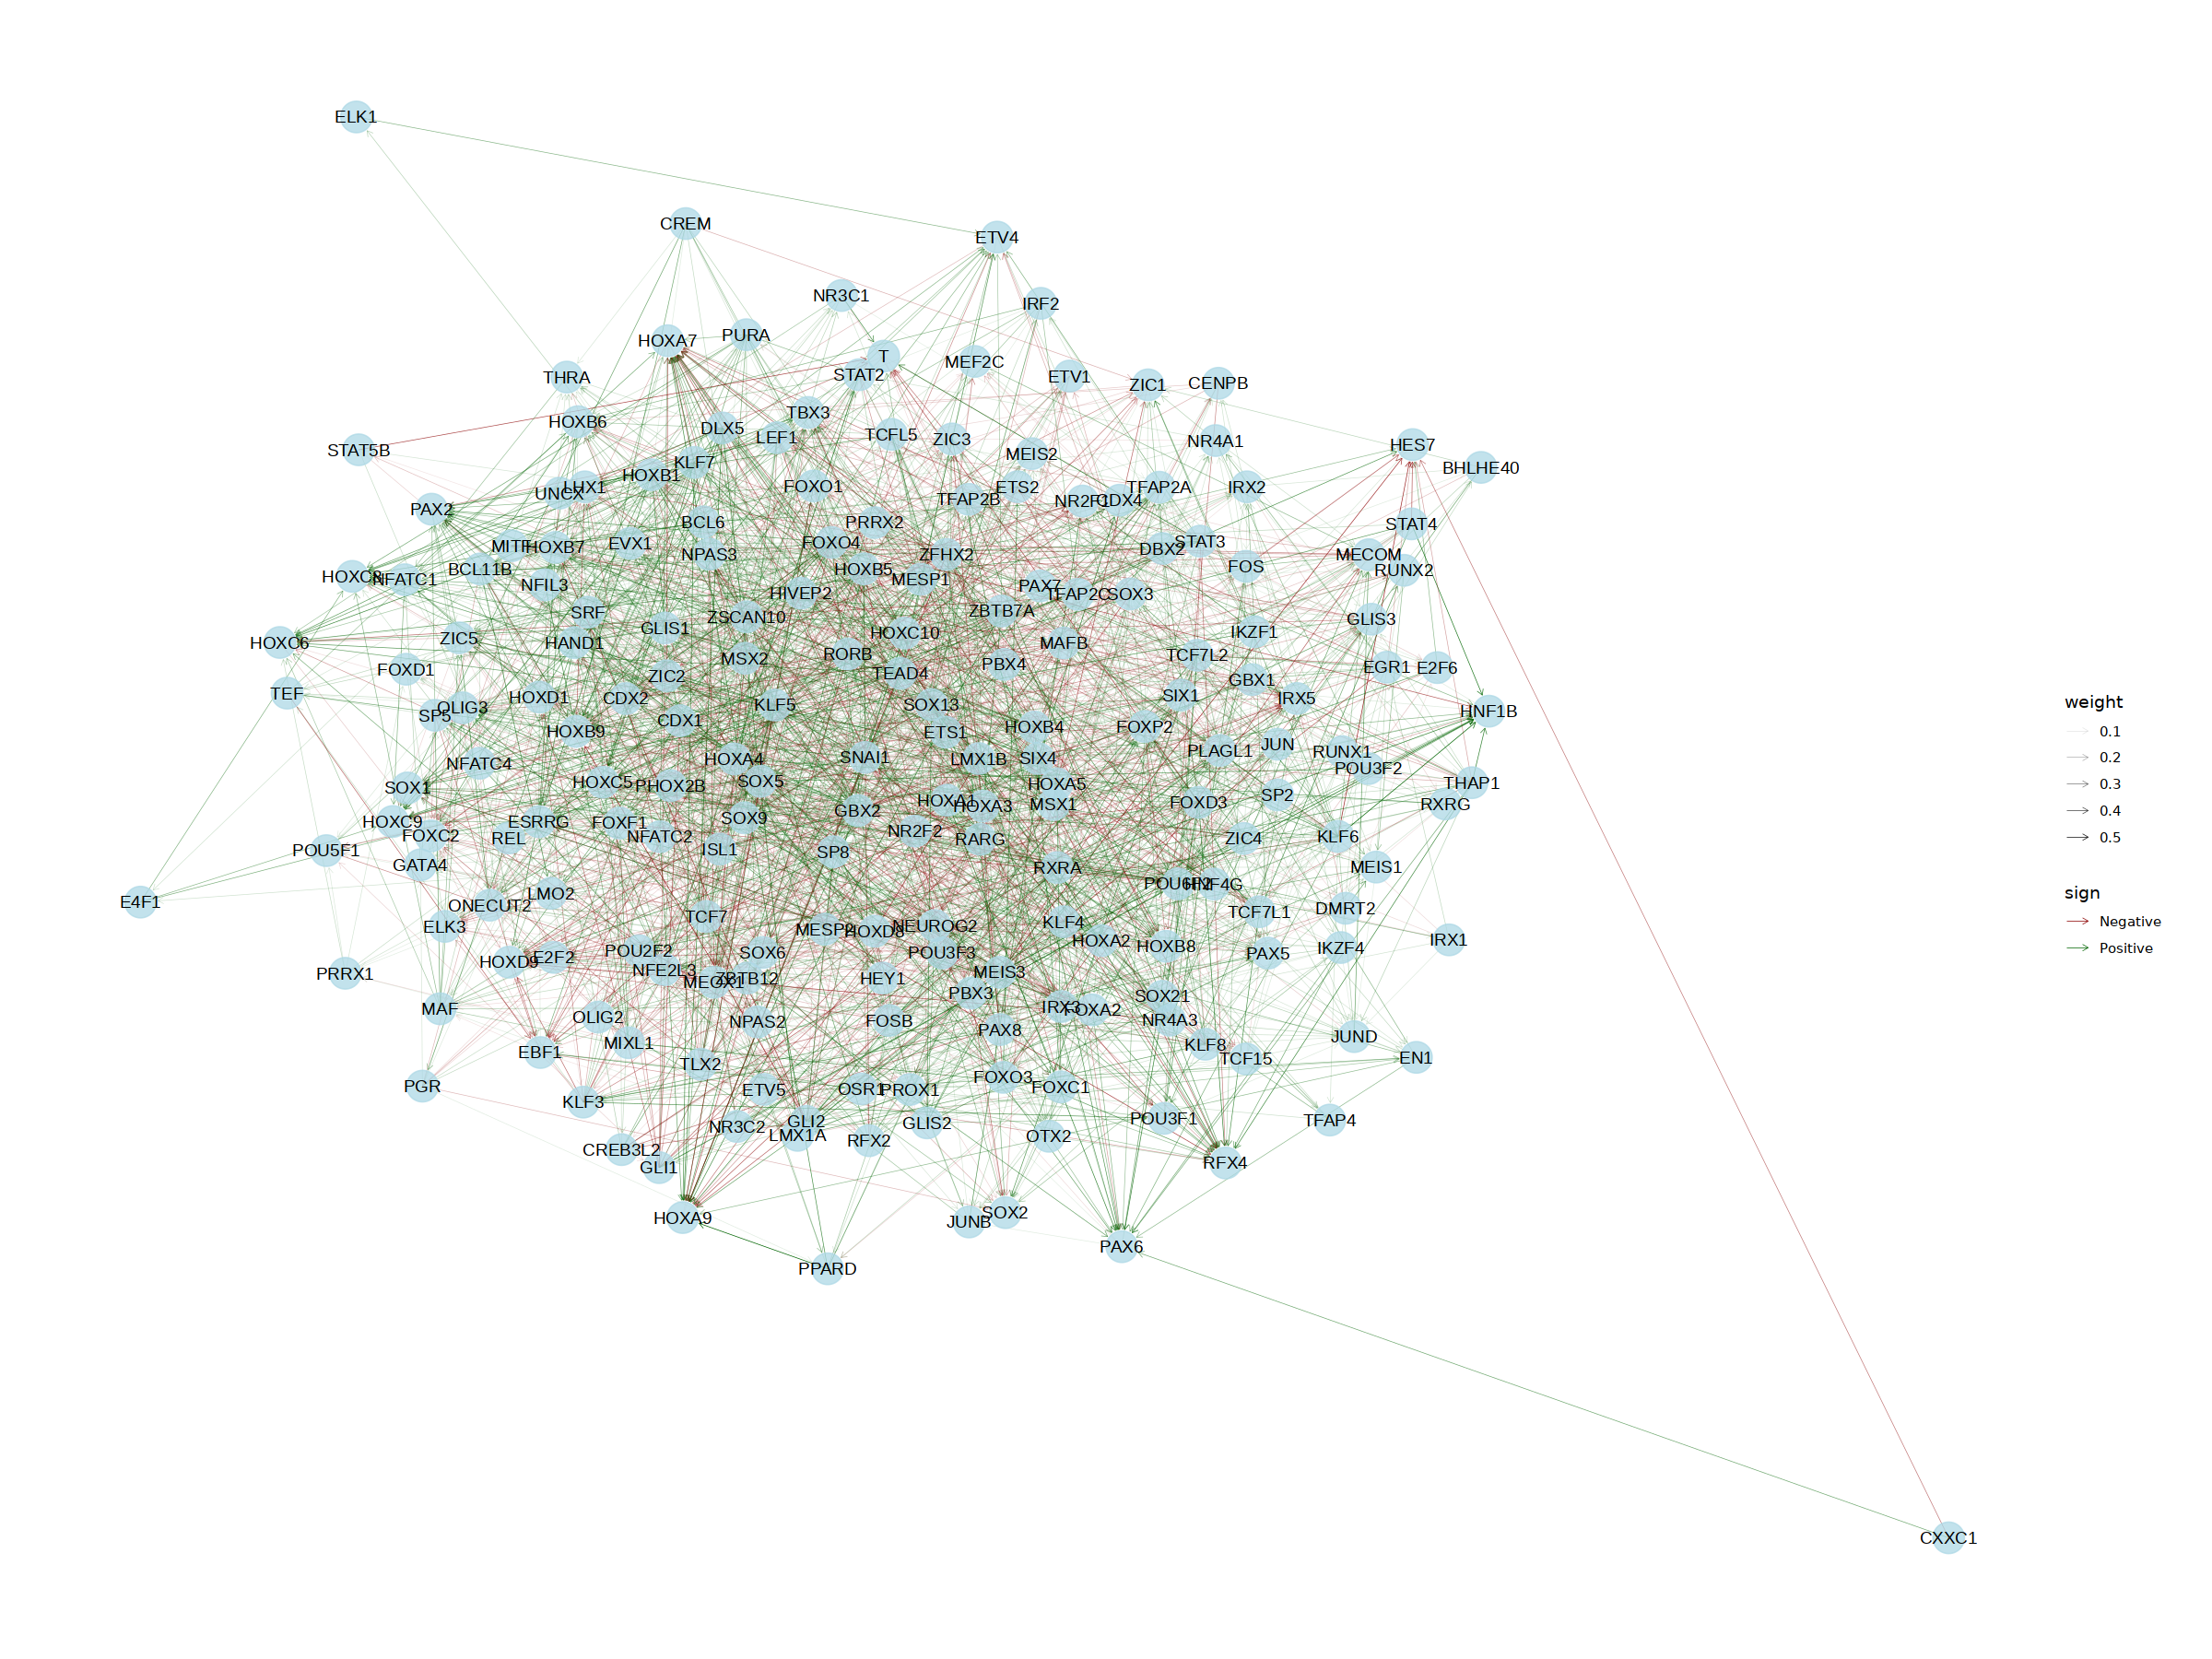

In [308]:
options(repr.plot.width=20, repr.plot.height=15)

ggraph(igraph.tbl, 'kk') +
  geom_edge_link(aes(edge_colour = sign, alpha=weight), edge_width=0.15, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  scale_edge_colour_manual(values=c("Positive"="darkgreen", "Negative"="darkred")) +
  geom_node_point(size=9, alpha=0.75, col='lightblue') +
  geom_node_text(aes(label = name)) +
  theme_graph()

In [309]:
# Create node and edge data.frames
GRN.dt = GRN.dt[beta>0]
TFs <- unique(c(GRN.dt$tf,GRN.dt$gene))
node_list.dt <- data.table(node_id=1:length(TFs), node_name=TFs)
edge_list.dt <- GRN.dt[,c("tf","gene","beta")] %>% setnames(c("from","to","weight")) %>% .[!from==to]

# Create igraph object
igraph.net <- graph_from_data_frame(d = edge_list.dt)

# Create tbl_graph object for ggraph
igraph.tbl <- as_tbl_graph(igraph.net) %>%
  activate(nodes) %>%
  mutate(tf=names(V(igraph.net))) %>%
  mutate(degree=igraph::degree(igraph.net)) %>%
  mutate(eigen_centrality=eigen_centrality(igraph.net)$vector) %>%
  activate(edges) %>%
  mutate(sign=ifelse(E(igraph.net)$weight>0,"Positive","Negative")) %>%
  mutate(weight=abs(weight))

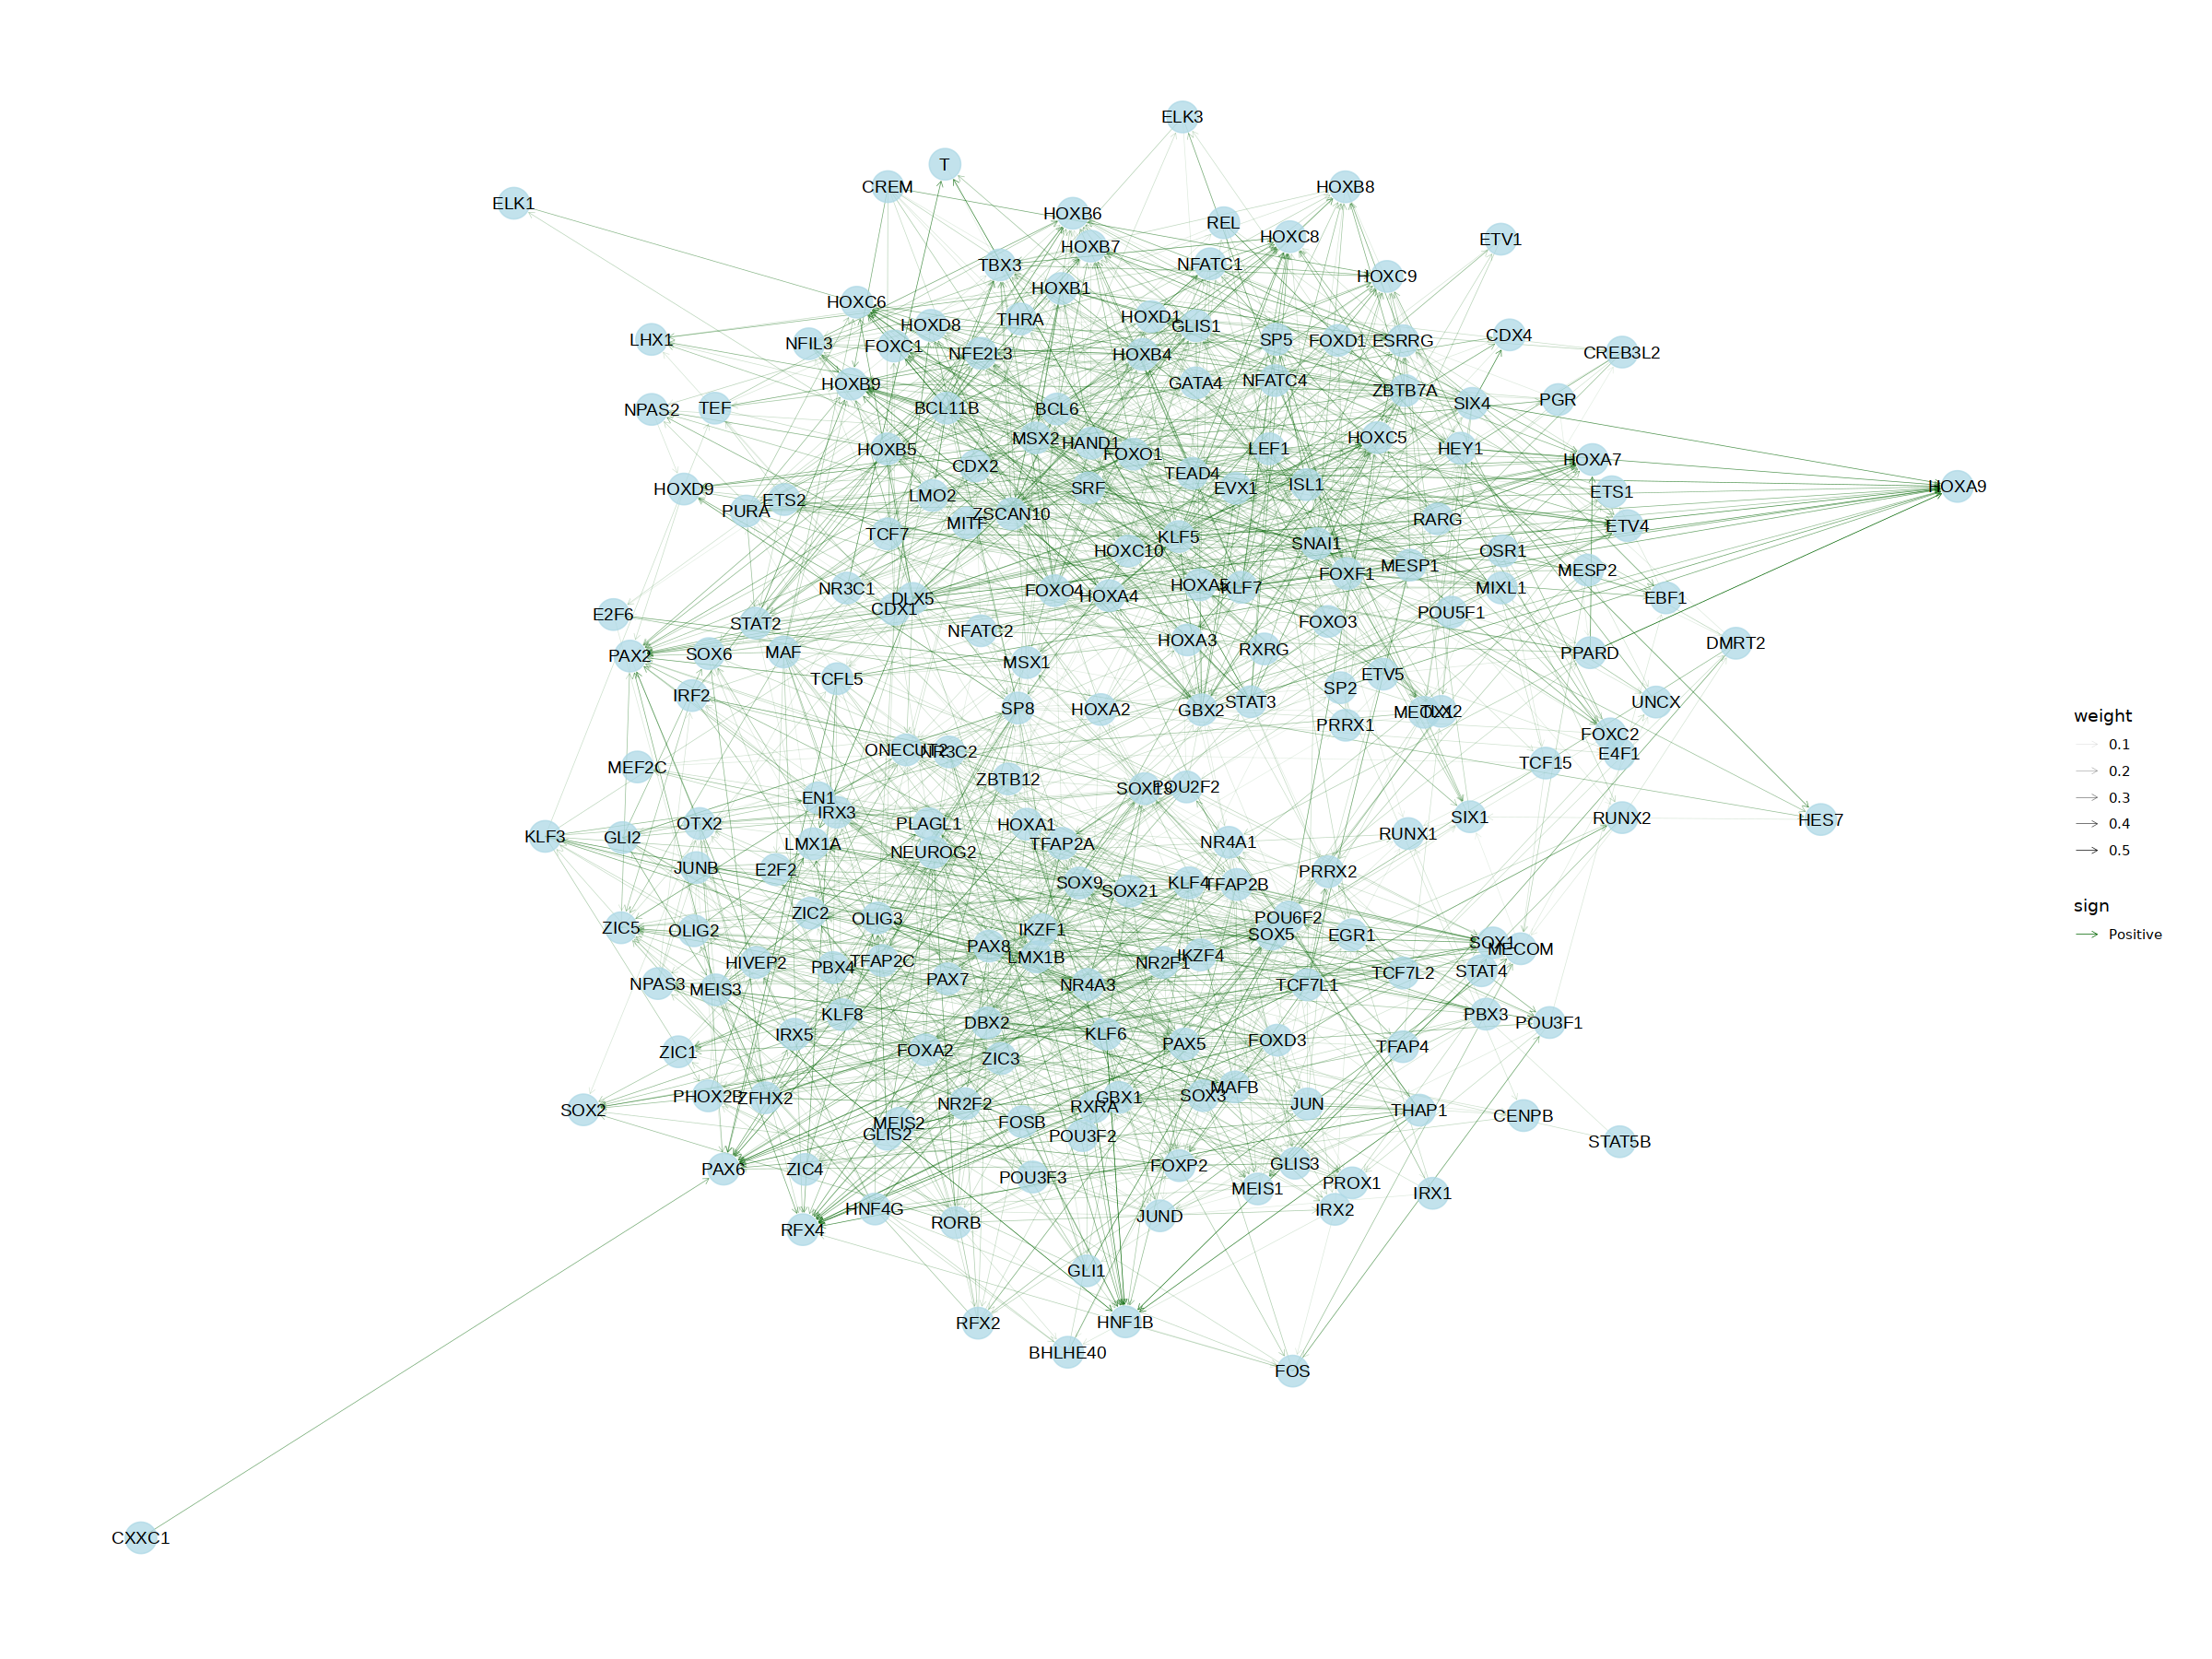

In [310]:
options(repr.plot.width=20, repr.plot.height=15)

ggraph(igraph.tbl, 'kk') +
  geom_edge_link(aes(edge_colour = sign, alpha=weight), edge_width=0.15, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  scale_edge_colour_manual(values=c("Positive"="darkgreen", "Negative"="darkred")) +
  geom_node_point(size=9, alpha=0.75, col='lightblue') +
  geom_node_text(aes(label = name)) +
  theme_graph()

In [133]:
io$cell2metacell <- file.path(io$outdir, "cell2metacell_assignment.txt.gz")


In [153]:
cell2metacell = fread(io$cell2metacell)

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


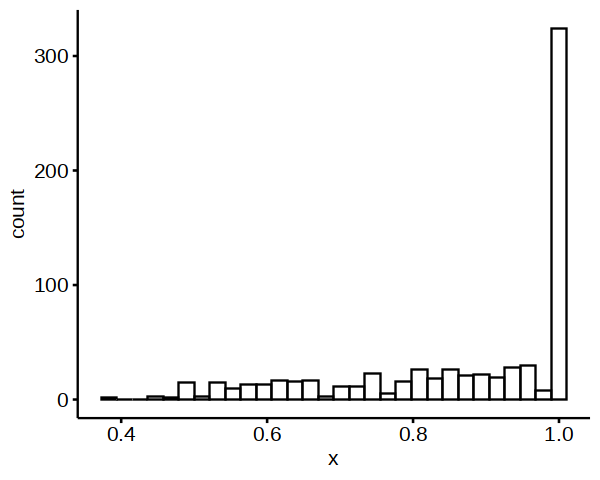

In [156]:
gghistogram(cell2metacell %>% unique(by='metacell') %>% .$celltype_purity)

In [154]:
head(cell2metacell)

cell,metacell,celltype,celltype_purity
<chr>,<chr>,<chr>,<dbl>
E7.5_rep1#AAACAGCCATCCTGAA-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep1#CTTAGTTTCATCCTCA-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep1#GCACATTAGTTTGGGT-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep1#TCACTGACAGGCTAAG-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep2#ACACGGACACCTGCTC-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep2#ATGAGCCGTAAATTGC-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
